# Semantic Propagation Code Workbook

This notebook does **not** embed pre-rendered SVG reports. It imports reusable Python functions from `scripts/semantic_propagation_analysis.py`, computes DataFrames, and draws plots live with matplotlib/seaborn.

Use kernel: **Taiwaneseness Analysis (.venv)**.

In [53]:
from pathlib import Path
import sys
import subprocess

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

from semantic_propagation_analysis import *

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130


## Load Frozen Corpus

In [54]:
df = load_frozen_corpus(ROOT / 'frozen_data_v2' / 'attestations_frozen.csv')
df.shape, df.columns.tolist()[-12:]

((1965, 46),
 ['capture_id',
  'search_id',
  'analysis_weight',
  'historical_binding_raw',
  'weighted_historical_binding',
  'source_ref',
  'is_positive',
  'five_year_bin',
  'decade',
  'semantic_family',
  'taiwan_marker_frame',
  'discourse_frame'])

In [55]:
df[['year','period','corridor','semantic_family','taiwan_marker_frame','discourse_frame','weighted_historical_binding','analysis_weight']].head(10)

,year,period,corridor,semantic_family,taiwan_marker_frame,discourse_frame,weighted_historical_binding,analysis_weight
0,1973,1946-1987_taiwan_side_formation,Taiwan-side,lurou_rouzao_core,taipei_metonym,consumer_or_retrospective_web,0.5708,0.5708
1,1952,1946-1987_taiwan_side_formation,Japan,taiwanese_cuisine_label,explicit_taiwan,consumer_or_retrospective_web,0.6247,0.6247
2,1952,1946-1987_taiwan_side_formation,Japan,taiwanese_cuisine_label,explicit_taiwan,consumer_or_retrospective_web,0.7600,0.7600
3,1958,1946-1987_taiwan_side_formation,Taiwan-side,lurou_rouzao_core,explicit_taiwan,other_discourse,0.9725,0.9725
4,1971,1946-1987_taiwan_side_formation,Taiwan-side,lurou_rouzao_core,taipei_metonym,other_discourse,0.9725,0.9725
5,1965,1946-1987_taiwan_side_formation,Taiwan-side,lurou_rouzao_core,south_taiwan_place,other_discourse,0.7600,0.7600
6,1980,1946-1987_taiwan_side_formation,unknown,taiwan_context_without_target_dish,explicit_taiwan,consumer_or_retrospective_web,0.0000,0.5691
7,1980,1946-1987_taiwan_side_formation,Japan,taiwanese_cuisine_label,explicit_taiwan,consumer_or_retrospective_web,0.5691,0.5691
8,1965,1946-1987_taiwan_side_formation,Taiwan-side,lurou_rouzao_core,south_taiwan_place,consumer_or_retrospective_web,0.7600,0.7600
9,2020,2014-2020_pre_wanghong_platformization,Yangtze River Delta,lurou_rouzao_core,explicit_taiwan,other_discourse,0.9100,0.9100


## One Table: Time × Geography × Semantics

`cube` is the main analysis table. It combines period, five-year bin, corridor, semantic family, Taiwan-marker frame, and discourse frame.

In [56]:
cube = semantic_propagation_cube(df)
cube.head(20)

,period,five_year_bin,corridor,semantic_family,taiwan_marker_frame,discourse_frame,row_count,weight_sum,binding_index,positive_rate_weighted,positive_rate_rows,primary_rows,secondary_rows,tertiary_rows,unique_sources,first_year,last_year
0,1940-1945_late_colonial_food_order,1930,Taiwan-side,lurou_rouzao_core,explicit_taiwan,official_tourism_memory,1,0.7600,1.0,1.0,1.0,0,0,1,1,1930,1930
1,1940-1945_late_colonial_food_order,1930,Taiwan-side,other_food_or_memory,explicit_taiwan,official_event_or_open_data,1,0.7600,1.0,1.0,1.0,0,0,1,1,1931,1931
2,1940-1945_late_colonial_food_order,1930,Taiwan-side,other_food_or_memory,explicit_taiwan,official_tourism_memory,2,1.5200,1.0,1.0,1.0,0,0,2,2,1931,1931
3,1940-1945_late_colonial_food_order,1935,Taiwan-side,lurou_rouzao_core,explicit_taiwan,official_tourism_memory,2,1.5200,1.0,1.0,1.0,0,0,2,2,1936,1938
4,1940-1945_late_colonial_food_order,1935,Taiwan-side,tea_drink_breakfast,explicit_taiwan,official_event_or_open_data,1,0.7600,1.0,1.0,1.0,0,0,1,1,1939,1939
5,1940-1945_late_colonial_food_order,1940,Taiwan-side,street_snack_xiaochi,explicit_taiwan,official_event_or_open_data,1,0.7600,1.0,1.0,1.0,0,0,1,1,1942,1942
7,1940-1945_preformation,1940,Taiwan-side,taiwanese_cuisine_label,explicit_taiwan,official_tourism_memory,1,0.5267,1.0,1.0,1.0,0,0,1,1,1940,1940
10,1946-1987_taiwan_side_formation,1945,Japan,lurou_rouzao_core,explicit_taiwan,archival_ad_or_news,1,1.0086,1.0,1.0,1.0,1,0,0,1,1947,1947
11,1946-1987_taiwan_side_formation,1945,Japan,lurou_rouzao_core,explicit_taiwan,consumer_or_retrospective_web,1,0.6880,1.0,1.0,1.0,0,0,1,1,1947,1947
12,1946-1987_taiwan_side_formation,1945,Japan,taiwan_context_without_target_dish,explicit_taiwan,other_discourse,1,0.8705,0.0,0.0,0.0,0,1,0,1,1947,1947


In [57]:
# Example: filter to early diffusion corridors and inspect semantic families over time.
early = cube[(cube['five_year_bin'] <= 2000) & (cube['corridor'].isin(['Singapore','Japan','North America','Mainland China']))]
early.sort_values(['five_year_bin','corridor','row_count'], ascending=[True, True, False]).head(30)

,period,five_year_bin,corridor,semantic_family,taiwan_marker_frame,discourse_frame,row_count,weight_sum,binding_index,positive_rate_weighted,positive_rate_rows,primary_rows,secondary_rows,tertiary_rows,unique_sources,first_year,last_year
10,1946-1987_taiwan_side_formation,1945,Japan,lurou_rouzao_core,explicit_taiwan,archival_ad_or_news,1,1.0086,1.0,1.0,1.0,1,0,0,1,1947,1947
11,1946-1987_taiwan_side_formation,1945,Japan,lurou_rouzao_core,explicit_taiwan,consumer_or_retrospective_web,1,0.6880,1.0,1.0,1.0,0,0,1,1,1947,1947
12,1946-1987_taiwan_side_formation,1945,Japan,taiwan_context_without_target_dish,explicit_taiwan,other_discourse,1,0.8705,0.0,0.0,0.0,0,1,0,1,1947,1947
23,1946-1987_taiwan_side_formation,1950,Japan,taiwanese_cuisine_label,explicit_taiwan,consumer_or_retrospective_web,2,1.3847,1.0,1.0,1.0,0,0,2,2,1952,1952
24,1946-1987_taiwan_side_formation,1950,Japan,taiwanese_cuisine_label,explicit_taiwan,other_discourse,1,0.7321,1.0,1.0,1.0,0,1,0,1,1951,1951
40,1946-1987_taiwan_side_formation,1955,Japan,taiwanese_cuisine_label,explicit_taiwan,consumer_or_retrospective_web,1,0.5850,1.0,1.0,1.0,0,0,1,1,1955,1955
41,1946-1987_taiwan_side_formation,1955,Japan,taiwanese_cuisine_label,explicit_taiwan,other_discourse,1,0.7350,1.0,1.0,1.0,0,1,0,1,1955,1955
42,1946-1987_taiwan_side_formation,1955,North America,other_food_or_memory,explicit_taiwan,other_discourse,1,0.9100,1.0,1.0,1.0,0,1,0,1,1955,1955
60,1946-1987_taiwan_side_formation,1960,Japan,taiwanese_cuisine_label,explicit_taiwan,brand_or_platform_listing,1,0.8322,1.0,1.0,1.0,0,1,0,1,1962,1962
61,1946-1987_taiwan_side_formation,1960,Japan,taiwanese_cuisine_label,explicit_taiwan,consumer_or_retrospective_web,1,0.7600,1.0,1.0,1.0,0,0,1,1,1963,1963


## Semantic Geography

In [58]:
geo = semantic_family_by_corridor(df)
geo[geo['corridor'].isin(KEY_CORRIDORS)].sort_values(['corridor','row_count'], ascending=[True, False]).head(40)

,corridor,semantic_family,row_count,weight_sum,binding_index,positive_rate_weighted,positive_rate_rows,primary_rows,secondary_rows,tertiary_rows,unique_sources,first_year,last_year,share_within_corridor
1,Hong Kong,tea_drink_breakfast,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,1996,1996,1.000000
6,Japan,taiwanese_cuisine_label,19,15.2170,1.000000,1.000000,1.000000,0,13,6,14,1951,1987,0.655172
2,Japan,lurou_rouzao_core,5,4.4266,1.000000,1.000000,1.000000,1,3,1,4,1947,2010,0.172414
4,Japan,other_food_or_memory,2,1.8200,1.000000,1.000000,1.000000,0,2,0,1,1984,1986,0.068966
3,Japan,noodle_soup_general,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,1967,1967,0.034483
5,Japan,taiwan_context_without_target_dish,1,0.8705,0.000000,0.000000,0.000000,0,1,0,1,1947,1947,0.034483
7,Japan,tea_drink_breakfast,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,2006,2006,0.034483
9,Korea,noodle_soup_general,2,1.9700,1.000000,1.000000,1.000000,1,1,0,2,2026,2026,0.500000
8,Korea,lurou_rouzao_core,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,2026,2026,0.250000
10,Korea,taiwanese_cuisine_label,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,2024,2024,0.250000


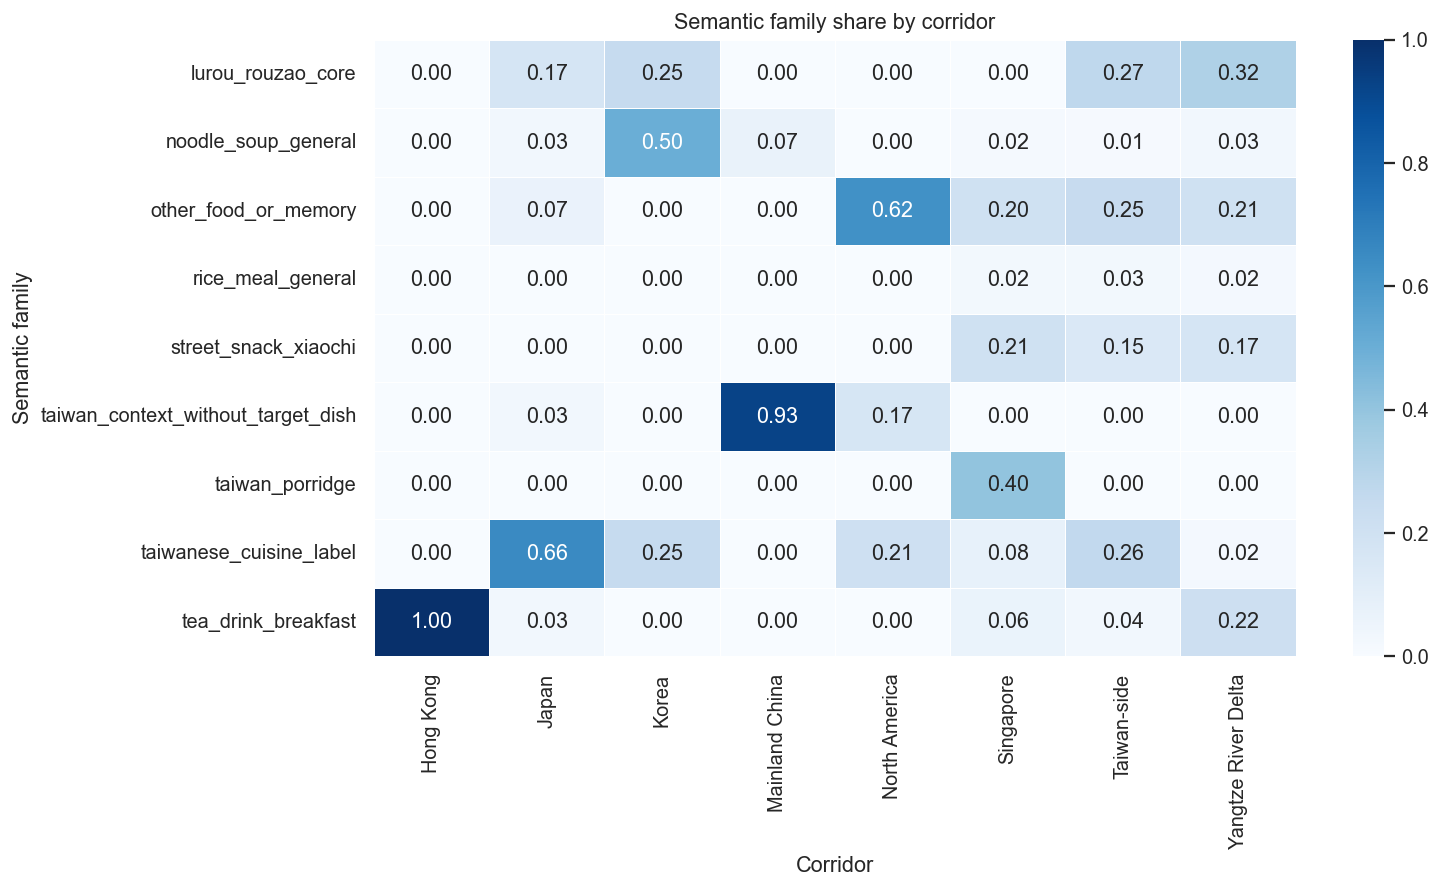

In [59]:
ax = plot_semantic_family_by_corridor(df, corridors=KEY_CORRIDORS)
plt.tight_layout()
plt.show()

## Semantic Change Over Time

In [60]:
time = semantic_family_by_time(df)
time.sort_values(['five_year_bin','row_count'], ascending=[True, False]).head(30)

,five_year_bin,semantic_family,row_count,weight_sum,binding_index,positive_rate_weighted,positive_rate_rows,primary_rows,secondary_rows,tertiary_rows,unique_sources,first_year,last_year,share_within_time_bin
1,1930,other_food_or_memory,3,2.2800,1.000000,1.000000,1.000000,0,0,3,3,1931,1931,0.750000
0,1930,lurou_rouzao_core,1,0.7600,1.000000,1.000000,1.000000,0,0,1,1,1930,1930,0.250000
2,1935,lurou_rouzao_core,2,1.5200,1.000000,1.000000,1.000000,0,0,2,2,1936,1938,0.666667
3,1935,tea_drink_breakfast,1,0.7600,1.000000,1.000000,1.000000,0,0,1,1,1939,1939,0.333333
4,1940,street_snack_xiaochi,1,0.7600,1.000000,1.000000,1.000000,0,0,1,1,1942,1942,0.500000
5,1940,taiwanese_cuisine_label,1,0.5267,1.000000,1.000000,1.000000,0,0,1,1,1940,1940,0.500000
6,1945,lurou_rouzao_core,6,5.0366,1.000000,1.000000,1.000000,1,2,3,5,1945,1949,0.333333
7,1945,other_food_or_memory,3,2.2800,1.000000,1.000000,1.000000,0,0,3,3,1946,1949,0.166667
12,1945,tea_drink_breakfast,3,2.2800,1.000000,1.000000,1.000000,0,0,3,1,1946,1947,0.166667
8,1945,rice_meal_general,2,1.5200,1.000000,1.000000,1.000000,0,0,2,2,1946,1947,0.111111


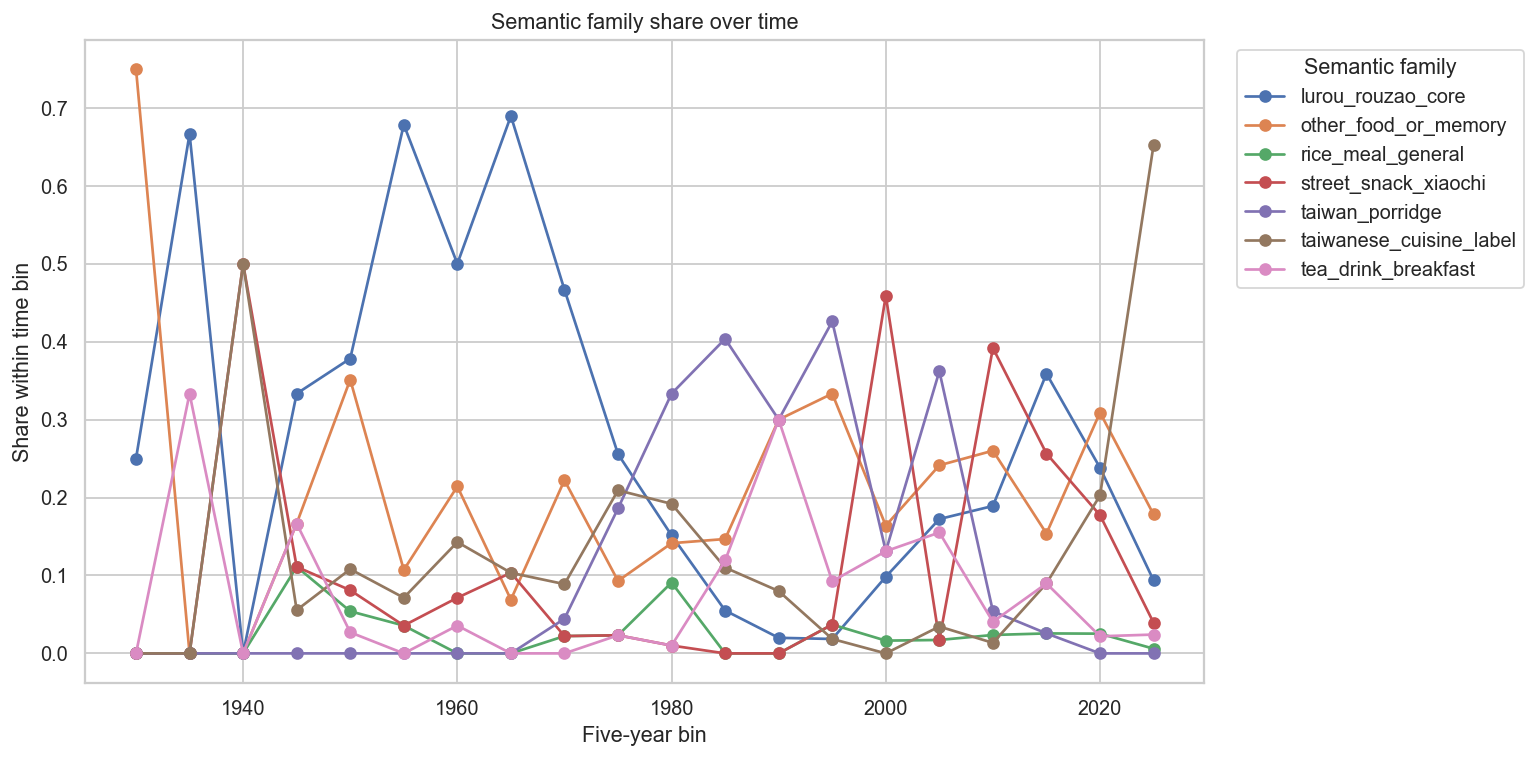

In [61]:
ax = plot_semantic_family_over_time(df, top_n=7)
plt.tight_layout()
plt.show()

## First Appearance by Corridor

In [62]:
first = semantic_first_appearance(df)
first.sort_values(['first_year','corridor','semantic_family']).head(40)

,corridor,semantic_family,rows,first_year,first_positive_year,last_year,binding_index,positive_rate_weighted,primary_rows,unique_sources
27,Taiwan-side,lurou_rouzao_core,362,1930,1930.0,2026,0.959610,0.959610,5,155
29,Taiwan-side,other_food_or_memory,331,1931,1931.0,2026,1.000000,1.000000,9,65
33,Taiwan-side,tea_drink_breakfast,47,1939,1939.0,2025,1.000000,1.000000,0,23
32,Taiwan-side,taiwanese_cuisine_label,352,1940,1940.0,2026,0.997159,0.997159,2,334
31,Taiwan-side,street_snack_xiaochi,197,1942,1942.0,2026,0.993818,0.993818,4,85
30,Taiwan-side,rice_meal_general,34,1946,1946.0,2025,1.000000,1.000000,2,26
2,Japan,lurou_rouzao_core,5,1947,1947.0,2010,1.000000,1.000000,1,4
5,Japan,taiwan_context_without_target_dish,1,1947,NaN,1947,0.000000,0.000000,0,1
6,Japan,taiwanese_cuisine_label,19,1951,1951.0,1987,1.000000,1.000000,0,14
13,North America,other_food_or_memory,15,1955,1955.0,2008,1.000000,1.000000,2,13


## When Attribution Is Too Obvious: Exceptions and Sensitivity

If the overall trend is saturated, inspect low-binding pockets and robustness to source types.

In [63]:
pockets = low_binding_pockets(df)
pockets.head(20)

,period,corridor,row_count,weight_sum,binding_index,positive_rate_weighted,positive_rate_rows,primary_rows,secondary_rows,tertiary_rows,unique_sources,first_year,last_year,grouping,source_type,authority_level,binding_gap
8,1946-1987_taiwan_side_formation,unknown,19,17.2993,0.000000,0.000000,0.000000,12,5,2,19,1970,1987,period + corridor,NaN,NaN,1.000000
58,1946-1987_taiwan_side_formation,Mainland China,13,13.7800,0.000000,0.000000,0.000000,13,0,0,5,1987,1987,period + corridor + source_type,newspaper_archive,NaN,1.000000
228,NaN,Mainland China,13,13.7800,0.000000,0.000000,0.000000,13,0,0,5,1987,1987,corridor + authority_level,NaN,primary,1.000000
132,1946-1987_taiwan_side_formation,unknown,12,11.4202,0.000000,0.000000,0.000000,12,0,0,12,1971,1987,period + corridor + source_type,newspaper_archive,NaN,1.000000
243,NaN,unknown,12,11.4202,0.000000,0.000000,0.000000,12,0,0,12,1971,1987,corridor + authority_level,NaN,primary,1.000000
244,NaN,unknown,5,4.5500,0.000000,0.000000,0.000000,0,5,0,5,1970,1985,corridor + authority_level,NaN,secondary,1.000000
9,1950-1978_taiwan_side_popular_food,Taiwan-side,4,3.4015,0.000000,0.000000,0.000000,0,3,1,3,1960,1973,period + corridor,NaN,NaN,1.000000
10,1979-1987_brand_formalization_and_reopening,Taiwan-side,3,2.3986,0.000000,0.000000,0.000000,0,2,1,2,1979,1987,period + corridor,NaN,NaN,1.000000
4,1946-1987_taiwan_side_formation,Mainland China,14,14.6900,0.061947,0.061947,0.071429,13,1,0,6,1987,1987,period + corridor,NaN,NaN,0.938053
160,1988-2001_cross_strait_mobility,Taiwan-side,3,2.5696,0.354141,0.354141,0.333333,0,3,0,1,1993,2000,period + corridor + source_type,official_brand_timeline,NaN,0.645859


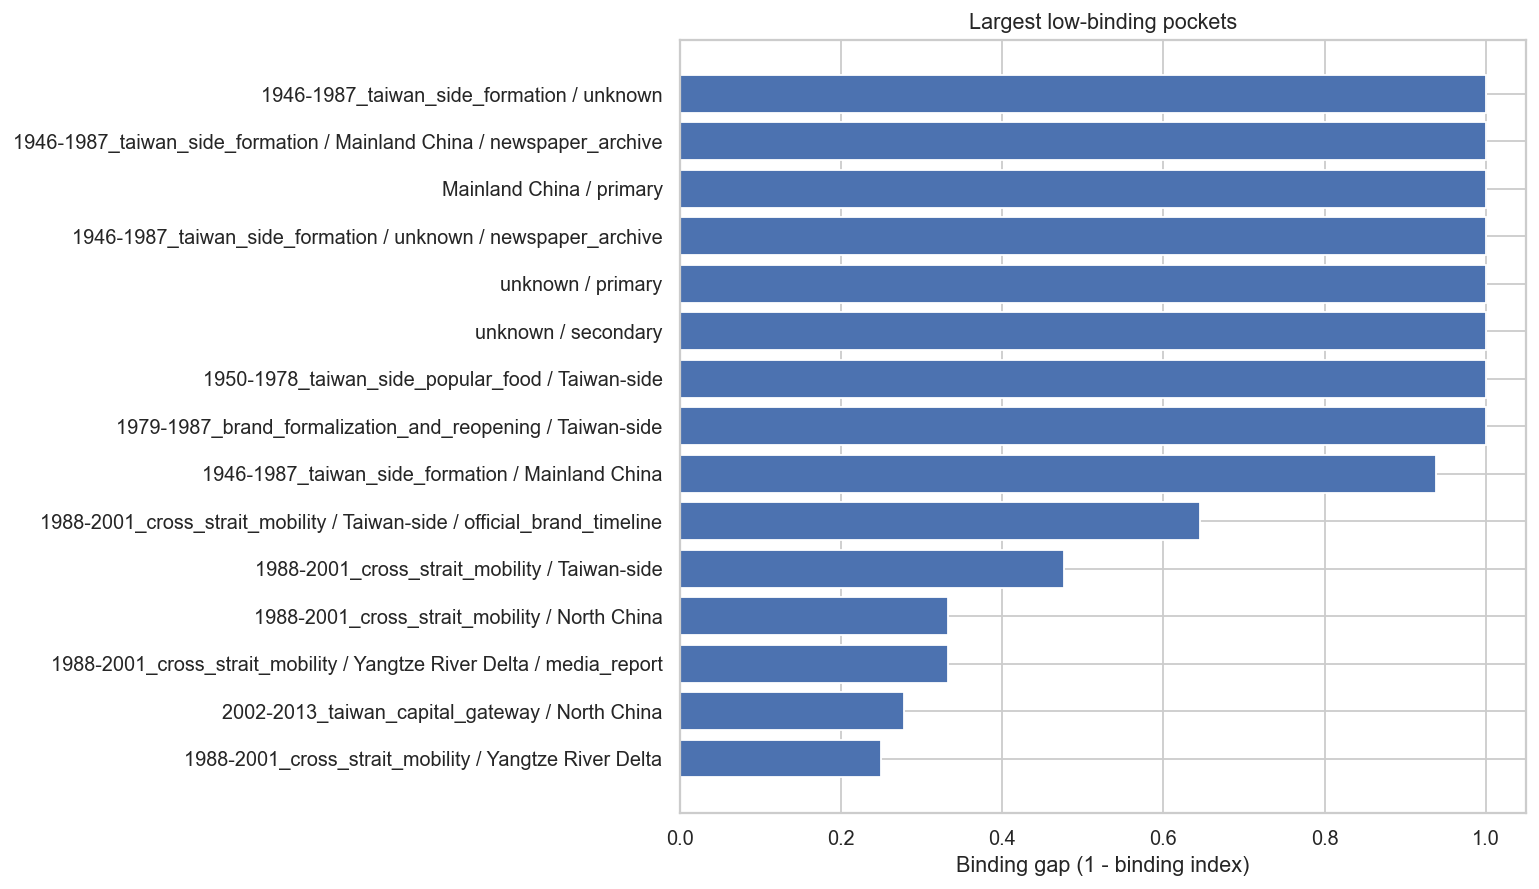

In [64]:
ax = plot_low_binding_pockets(df, n=15)
plt.tight_layout()
plt.show()

In [65]:
sensitivity = leave_one_source_type_out(df)
sensitivity.sort_values('delta_from_full_index').head(20)

,excluded_source_type,excluded_rows,excluded_share,binding_index_without_source_type,delta_from_full_index
26,official_open_data,358,0.182188,0.955370,-0.007705
22,official_event_page,349,0.177608,0.956577,-0.006498
16,newspaper_issue,227,0.115522,0.957313,-0.005762
31,official_tourism_profile,163,0.082952,0.959981,-0.003094
11,municipal_profile,38,0.019338,0.962386,-0.000689
29,official_tourism_file,40,0.020356,0.962479,-0.000596
25,official_itinerary_file,32,0.016285,0.962521,-0.000555
23,official_food_competition_file,32,0.016285,0.962551,-0.000524
3,corporate_prospectus,24,0.012214,0.962556,-0.000519
32,official_tourism_route,25,0.012723,0.962625,-0.000451


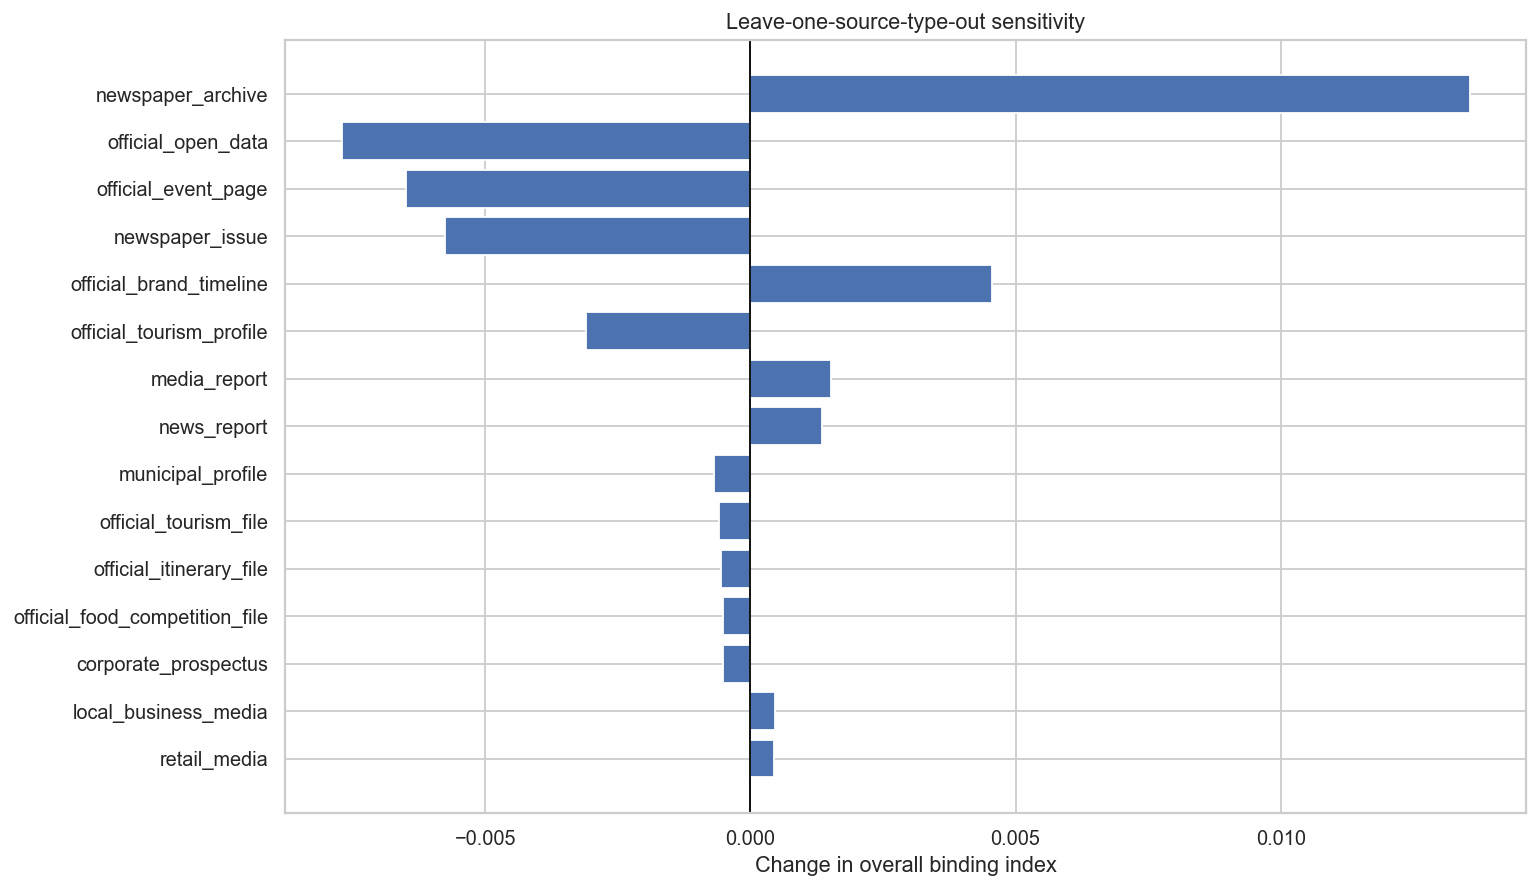

In [66]:
ax = plot_leave_one_source_type_out(df, n=15)
plt.tight_layout()
plt.show()

## Export Optional Tables

These exports are optional. The notebook analysis itself is live code.

In [67]:
out = ROOT / 'analysis' / 'semantic_propagation_live_outputs'
out.mkdir(parents=True, exist_ok=True)
cube.to_csv(out / 'semantic_propagation_cube.csv', index=False)
geo.to_csv(out / 'semantic_family_by_corridor.csv', index=False)
time.to_csv(out / 'semantic_family_by_time.csv', index=False)
first.to_csv(out / 'semantic_first_appearance.csv', index=False)
pockets.to_csv(out / 'low_binding_pockets.csv', index=False)
sensitivity.to_csv(out / 'leave_one_source_type_out.csv', index=False)
out

PosixPath('/Users/jarlgiovanni/Desktop/Taiwaneseness as a consumed cultural sign/analysis/semantic_propagation_live_outputs')

## Main Visual Evidence Panels

This is the section to use for thesis analysis. It regenerates the live analysis outputs, then displays the PNG figures and CSV tables inside the notebook. The point is not a single flat trend line; it is semantic propagation across **time × corridor × semantic family × discourse frame**.


In [68]:
# Regenerate the live code outputs so the notebook is not relying on stale embedded images.
LIVE_SCRIPT = ROOT / "analysis" / "semantic_propagation_live.py"
subprocess.run([sys.executable, str(LIVE_SCRIPT)], check=True)

OUT_DIR = ROOT / "analysis" / "semantic_propagation_live_outputs"
FIG_DIR = OUT_DIR / "figures"
TABLES = {p.stem: p for p in sorted(OUT_DIR.glob("*.csv"))}
FIGURES = {p.stem: p for p in sorted(FIG_DIR.glob("*.png"))}
print(f"Tables: {len(TABLES)} | Figures: {len(FIGURES)}")
sorted(FIGURES)


(1965, 46)
(383, 17)
/Users/jarlgiovanni/Desktop/Taiwaneseness as a consumed cultural sign/analysis/semantic_propagation_live_outputs
Tables: 7 | Figures: 18


['corridor_time_primary_share',
 'corridor_time_record_volume',
 'discourse_stack_Japan',
 'discourse_stack_North_America',
 'discourse_stack_Singapore',
 'discourse_stack_Taiwan_side',
 'discourse_stack_Yangtze_River_Delta',
 'first_appearance_timeline',
 'leave_one_source_type_out',
 'low_binding_pockets',
 'semantic_entropy_by_corridor',
 'semantic_family_by_corridor',
 'semantic_family_over_time',
 'semantic_stack_Japan',
 'semantic_stack_North_America',
 'semantic_stack_Singapore',
 'semantic_stack_Taiwan_side',
 'semantic_stack_Yangtze_River_Delta']

### A. The propagation map: when each semantic family first becomes visible

Use this as the clearest alternative to a saturated trend line. It asks **which semantic package appears where first**, rather than forcing a single overall binding slope.


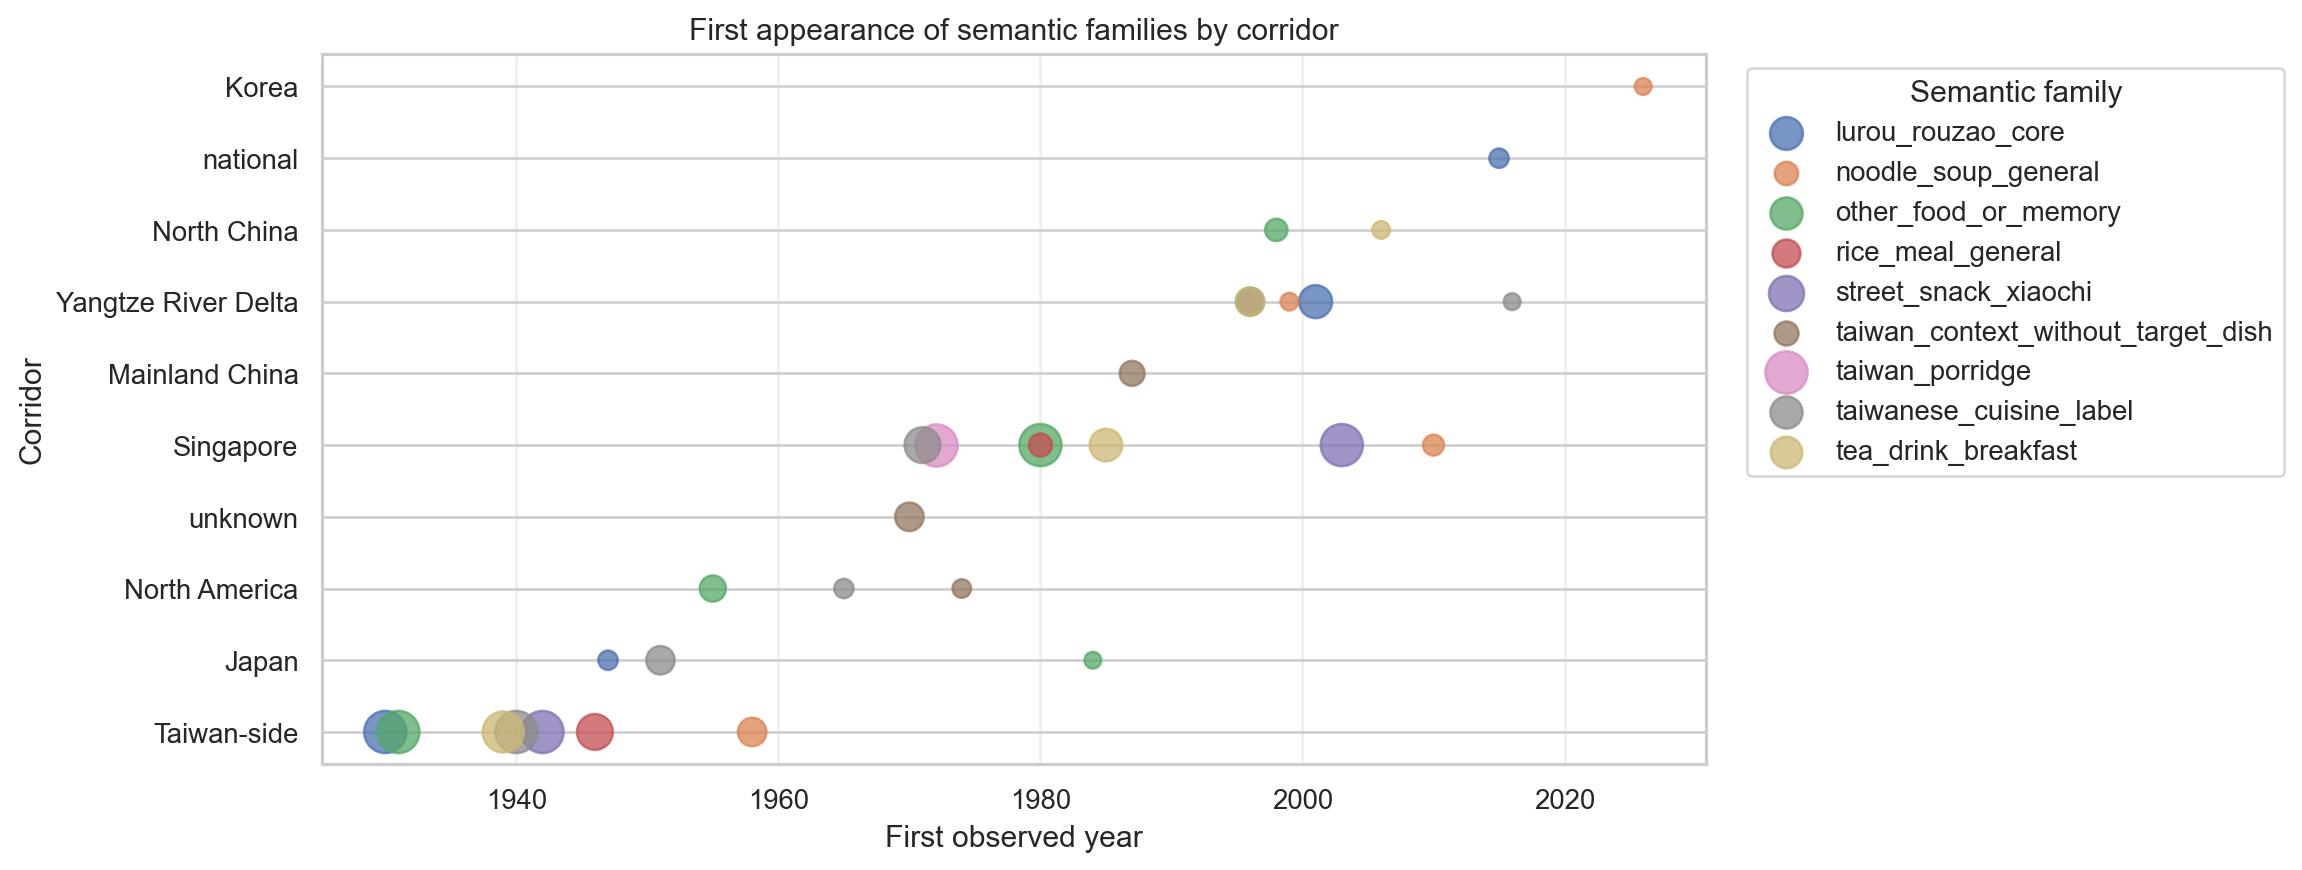

,corridor,semantic_family,rows,first_year,first_positive_year,last_year,binding_index,positive_rate_weighted,primary_rows,unique_sources
0,Taiwan-side,lurou_rouzao_core,362,1930,1930.0,2026,0.959610,0.959610,5,155
1,Taiwan-side,other_food_or_memory,331,1931,1931.0,2026,1.000000,1.000000,9,65
2,Taiwan-side,tea_drink_breakfast,47,1939,1939.0,2025,1.000000,1.000000,0,23
3,Taiwan-side,taiwanese_cuisine_label,352,1940,1940.0,2026,0.997159,0.997159,2,334
4,Taiwan-side,street_snack_xiaochi,197,1942,1942.0,2026,0.993818,0.993818,4,85
5,Taiwan-side,rice_meal_general,34,1946,1946.0,2025,1.000000,1.000000,2,26
6,Japan,lurou_rouzao_core,5,1947,1947.0,2010,1.000000,1.000000,1,4
7,Japan,taiwan_context_without_target_dish,1,1947,NaN,1947,0.000000,0.000000,0,1
8,Japan,taiwanese_cuisine_label,19,1951,1951.0,1987,1.000000,1.000000,0,14
9,North America,other_food_or_memory,15,1955,1955.0,2008,1.000000,1.000000,2,13


In [69]:
display(Image(filename=str(FIGURES["first_appearance_timeline"])))
first = pd.read_csv(TABLES["semantic_first_appearance"])
display(first.sort_values(["first_year", "corridor", "semantic_family"]).head(30))


### B. Time × geography: record density and source quality

These two heatmaps keep quantity and quality separate. A period can look semantically strong while still being weakly supported by primary evidence.


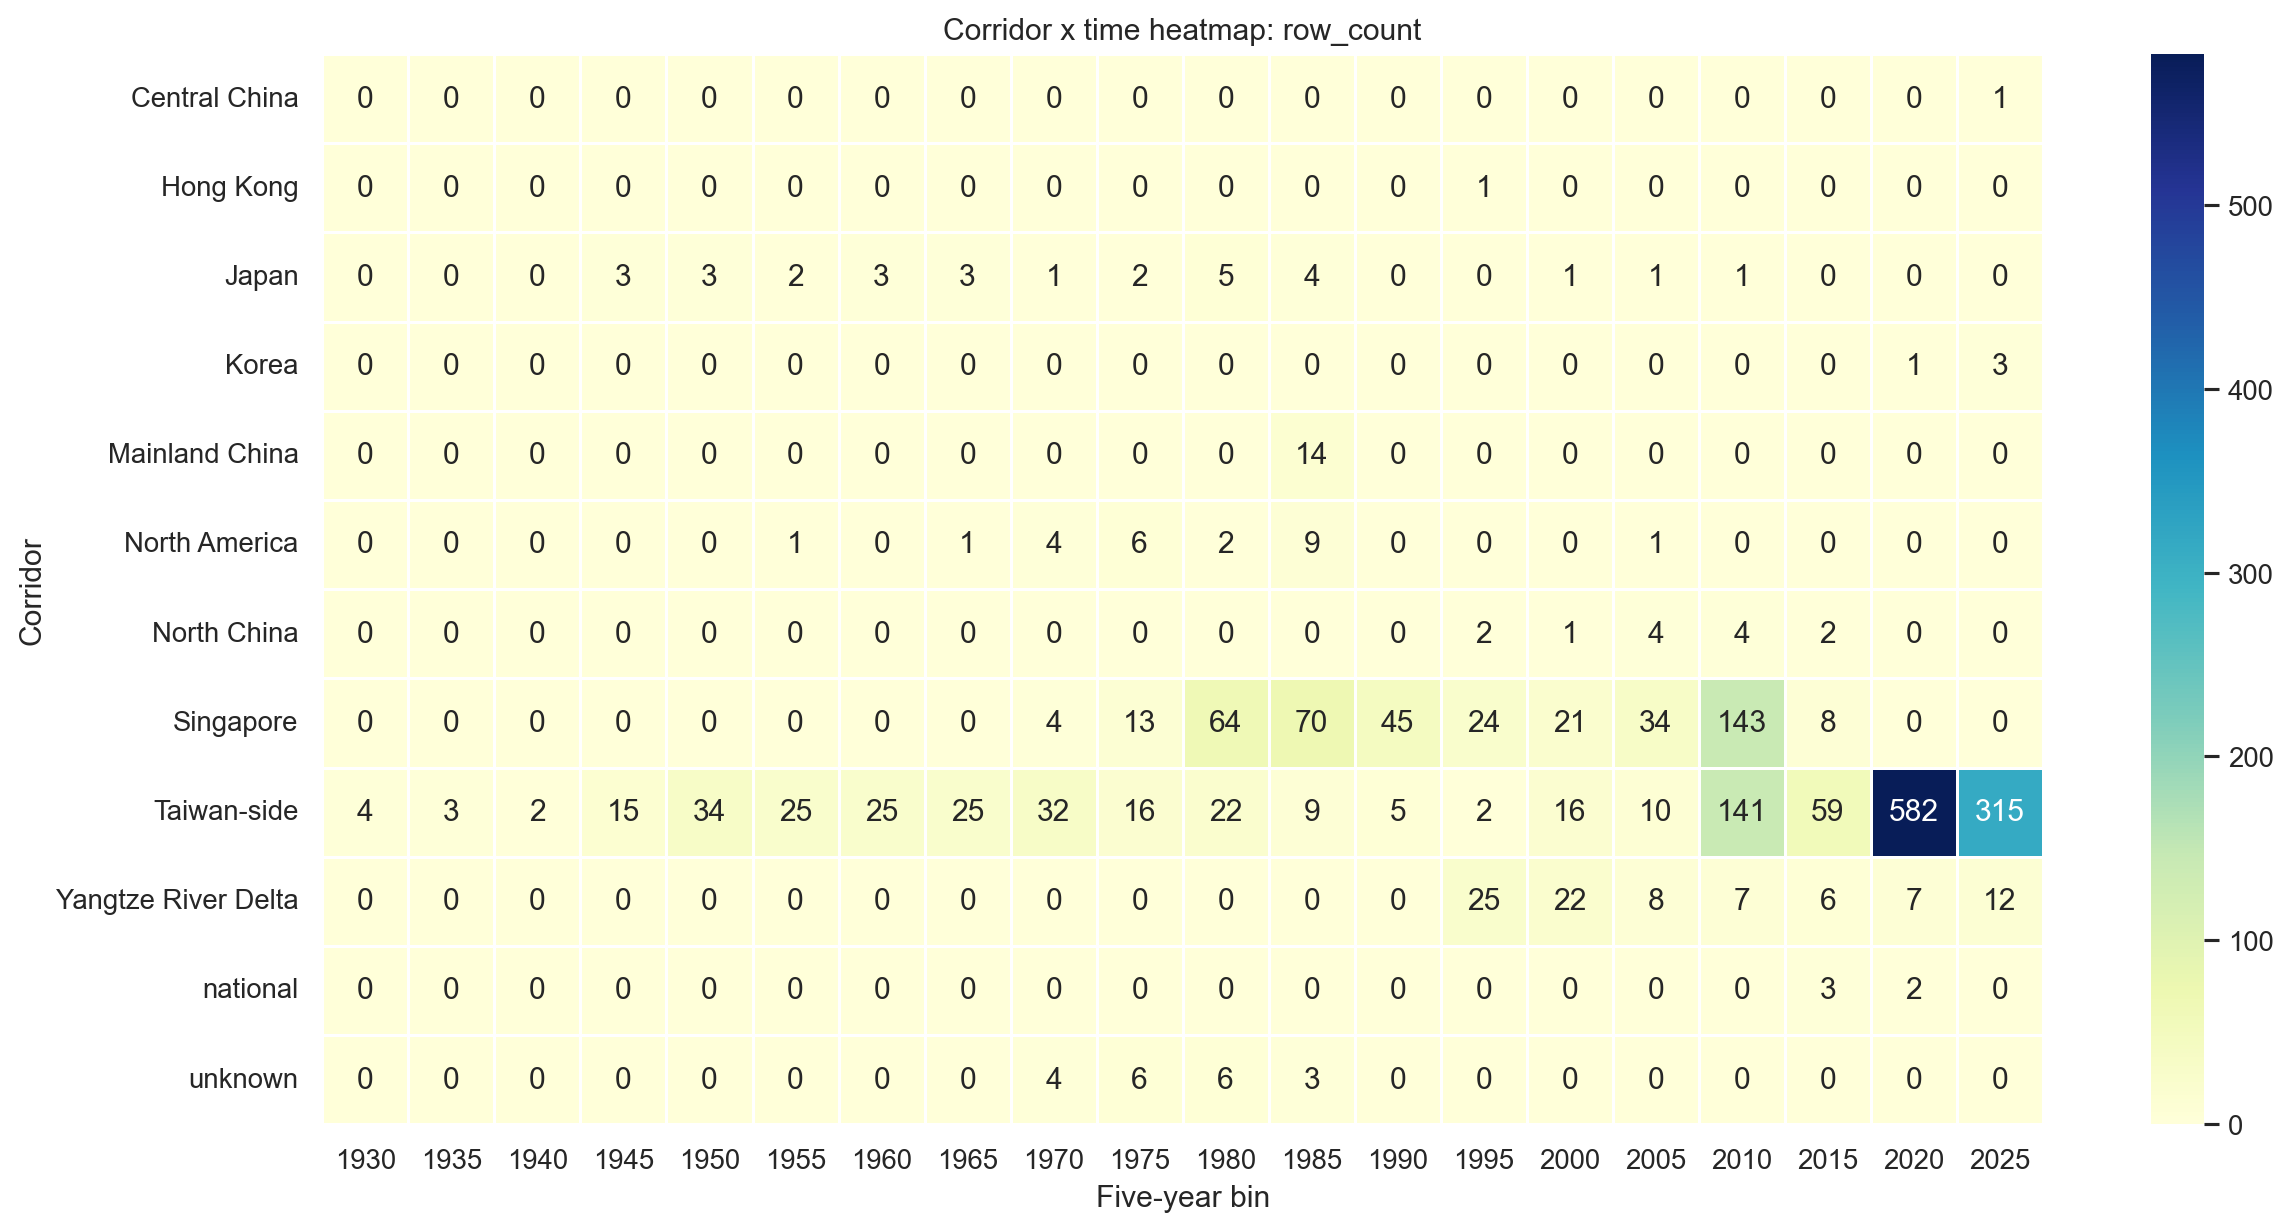

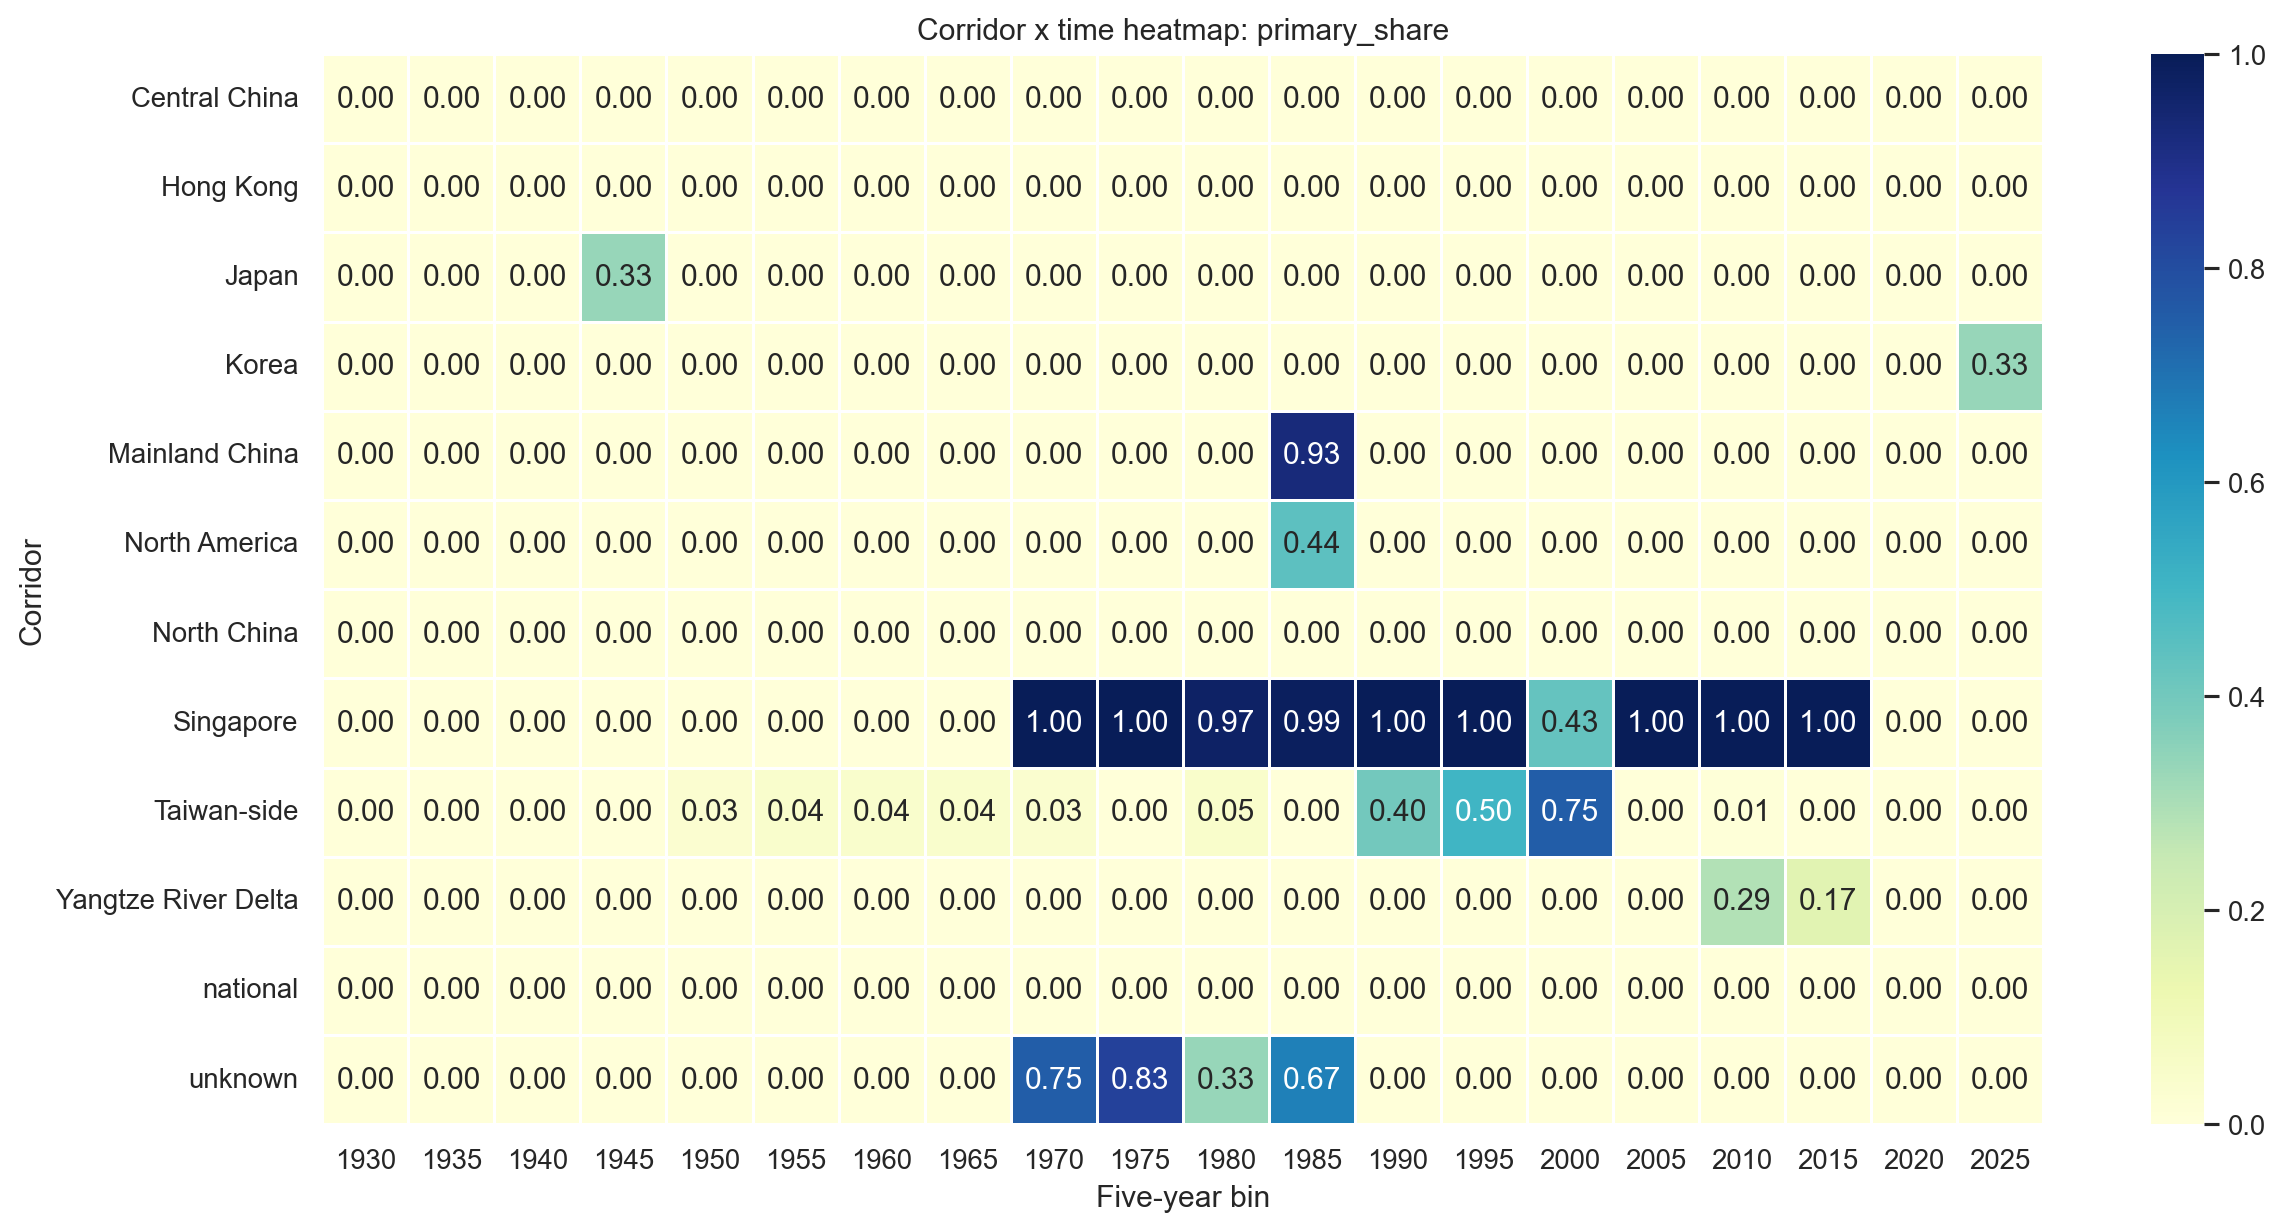

,corridor,five_year_bin,row_count,weight_sum,binding_index,positive_rate_weighted,primary_share,tertiary_share,unique_sources,semantic_entropy,semantic_entropy_normalized,dominant_semantic_family,dominant_semantic_share
39,Taiwan-side,1930,4,3.0400,1.000000,1.000000,0.000000,1.000000,4,0.811278,0.811278,other_food_or_memory,0.750000
40,Taiwan-side,1935,3,2.2800,1.000000,1.000000,0.000000,1.000000,3,0.918296,0.918296,lurou_rouzao_core,0.666667
41,Taiwan-side,1940,2,1.2867,1.000000,1.000000,0.000000,1.000000,2,1.000000,1.000000,street_snack_xiaochi,0.500000
42,Taiwan-side,1945,15,11.7000,1.000000,1.000000,0.000000,0.866667,10,2.472906,0.956650,lurou_rouzao_core,0.266667
2,Japan,1945,3,2.5671,0.660901,0.660901,0.333333,0.333333,3,0.918296,0.918296,lurou_rouzao_core,0.666667
43,Taiwan-side,1950,34,25.8224,1.000000,1.000000,0.029412,0.794118,23,1.906181,0.737412,lurou_rouzao_core,0.411765
3,Japan,1950,3,2.1168,1.000000,1.000000,0.000000,0.666667,3,-0.000000,0.000000,taiwanese_cuisine_label,1.000000
44,Taiwan-side,1955,25,18.3198,1.000000,1.000000,0.040000,0.720000,20,1.255431,0.540685,lurou_rouzao_core,0.760000
4,Japan,1955,2,1.3200,1.000000,1.000000,0.000000,0.500000,2,-0.000000,0.000000,taiwanese_cuisine_label,1.000000
17,North America,1955,1,0.9100,1.000000,1.000000,0.000000,0.000000,1,-0.000000,0.000000,other_food_or_memory,1.000000


In [70]:
display(Image(filename=str(FIGURES["corridor_time_record_volume"])))
display(Image(filename=str(FIGURES["corridor_time_primary_share"])))
summary = pd.read_csv(TABLES["corridor_time_summary"])
display(summary.sort_values(["five_year_bin", "row_count"], ascending=[True, False]).head(35))


### C. Semantic diversity: where the story has real variation

Entropy is useful here because the overall binding index is saturated. Higher entropy means a corridor uses more than one semantic route into Taiwaneseness.


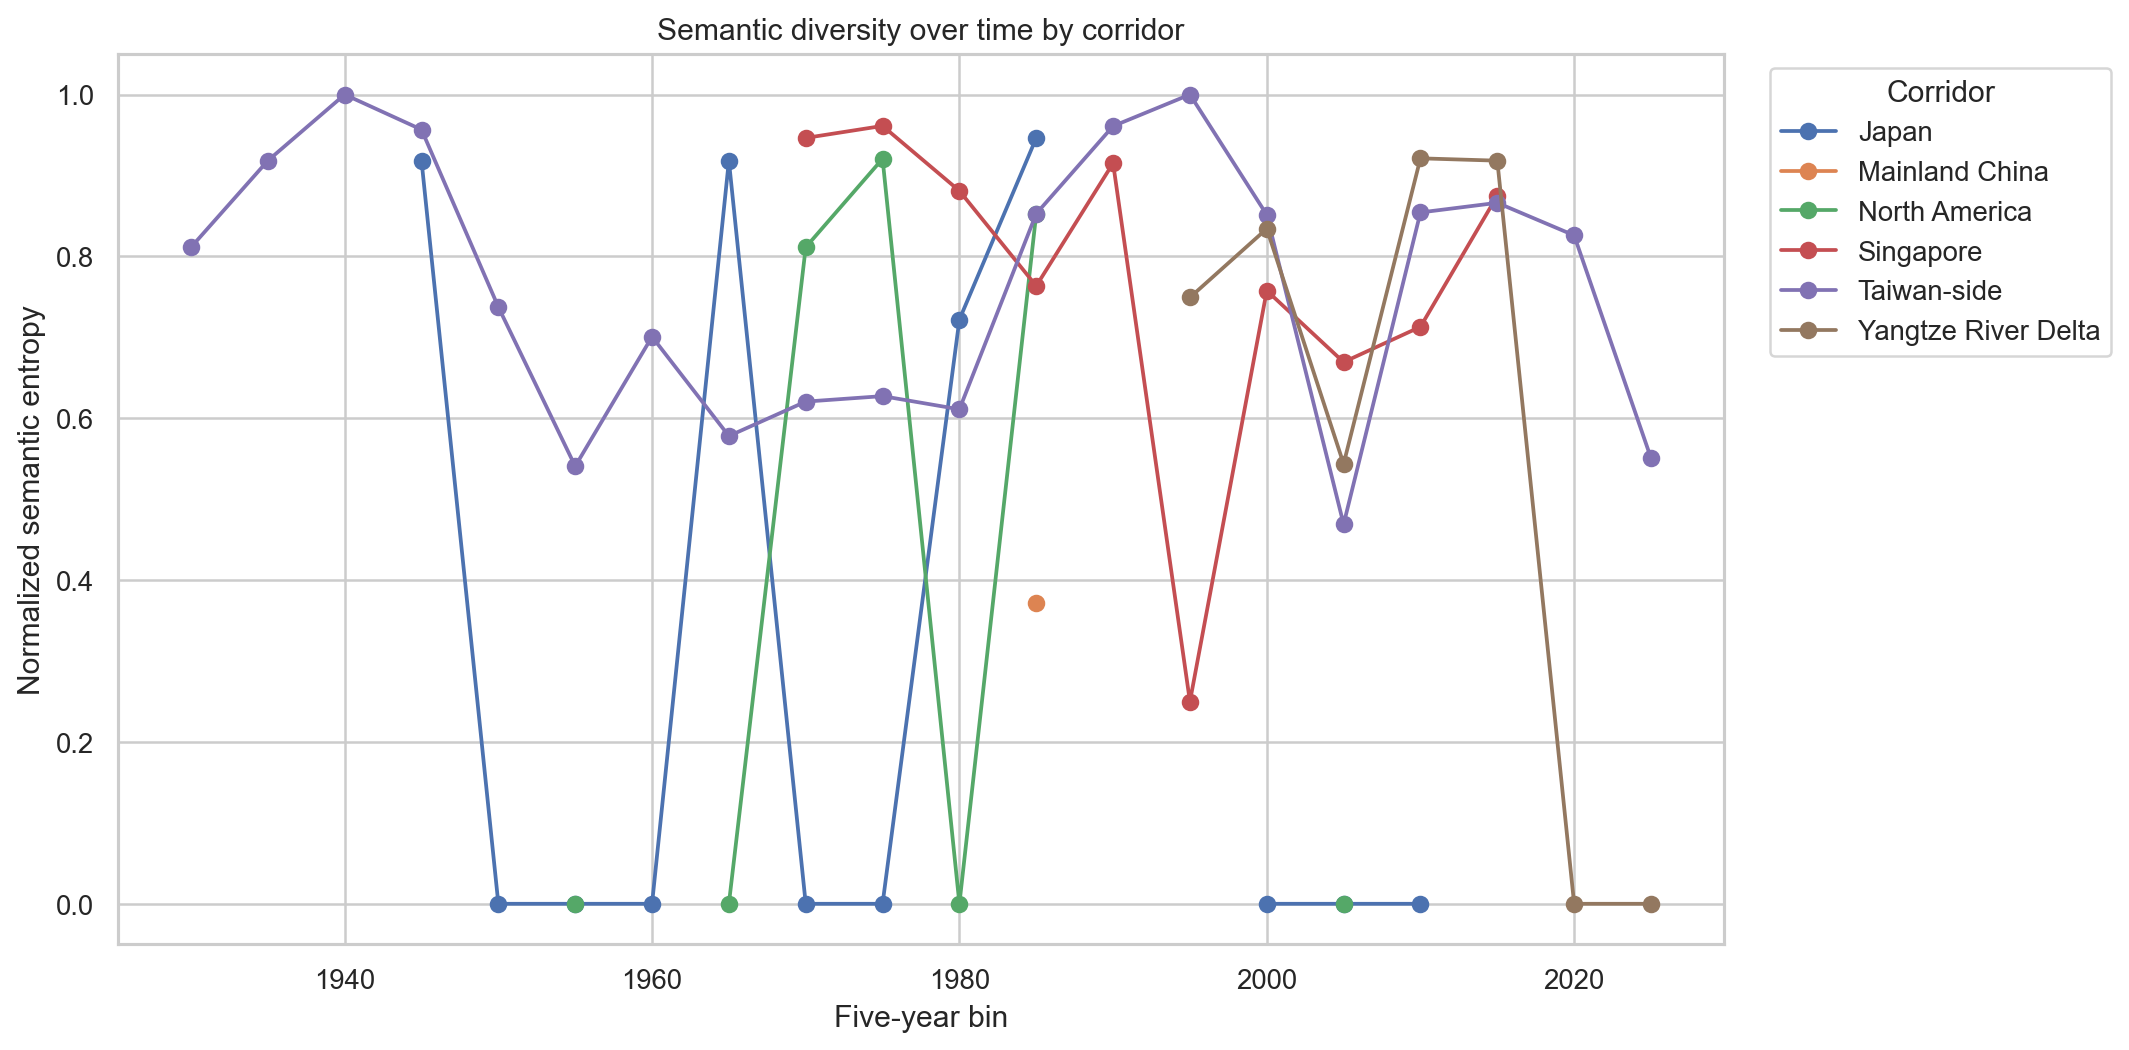

,corridor,semantic_family,row_count,weight_sum,binding_index,positive_rate_weighted,positive_rate_rows,primary_rows,secondary_rows,tertiary_rows,unique_sources,first_year,last_year,share_within_corridor
0,Central China,lurou_rouzao_core,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,2025,2025,1.000000
1,Hong Kong,tea_drink_breakfast,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,1996,1996,1.000000
2,Japan,taiwanese_cuisine_label,19,15.2170,1.000000,1.000000,1.000000,0,13,6,14,1951,1987,0.655172
3,Japan,lurou_rouzao_core,5,4.4266,1.000000,1.000000,1.000000,1,3,1,4,1947,2010,0.172414
4,Japan,other_food_or_memory,2,1.8200,1.000000,1.000000,1.000000,0,2,0,1,1984,1986,0.068966
5,Japan,noodle_soup_general,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,1967,1967,0.034483
6,Japan,taiwan_context_without_target_dish,1,0.8705,0.000000,0.000000,0.000000,0,1,0,1,1947,1947,0.034483
7,Japan,tea_drink_breakfast,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,2006,2006,0.034483
8,Korea,noodle_soup_general,2,1.9700,1.000000,1.000000,1.000000,1,1,0,2,2026,2026,0.500000
9,Korea,lurou_rouzao_core,1,0.9100,1.000000,1.000000,1.000000,0,1,0,1,2026,2026,0.250000


In [71]:
display(Image(filename=str(FIGURES["semantic_entropy_by_corridor"])))
geo = pd.read_csv(TABLES["semantic_family_by_corridor"])
display(geo.sort_values(["corridor", "row_count"], ascending=[True, False]).head(50))


### D. Corridor-specific semantic stacks

These are the strongest visual evidence panels. They show composition and change, so the argument does not depend on a single positive/negative binding score.


#### semantic stack Taiwan side

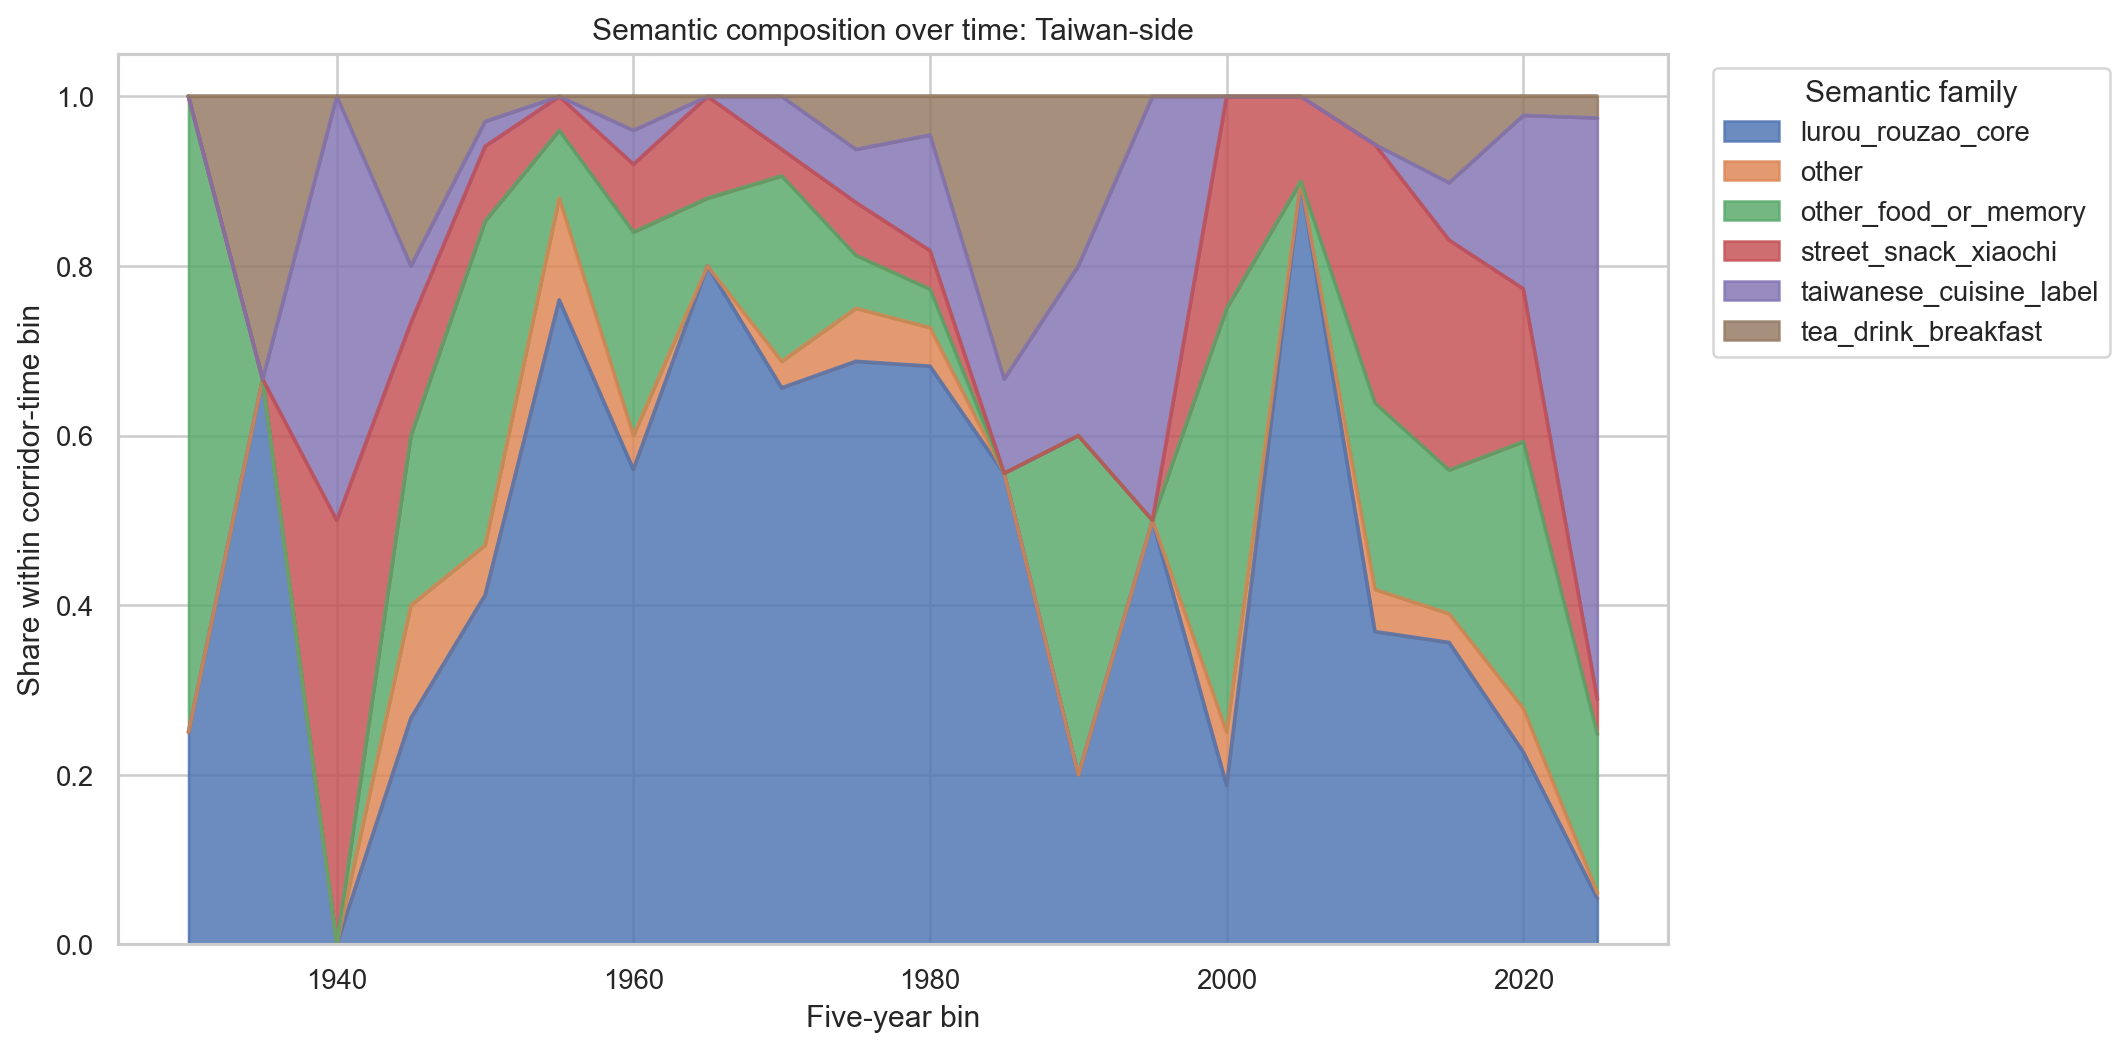

#### semantic stack Singapore

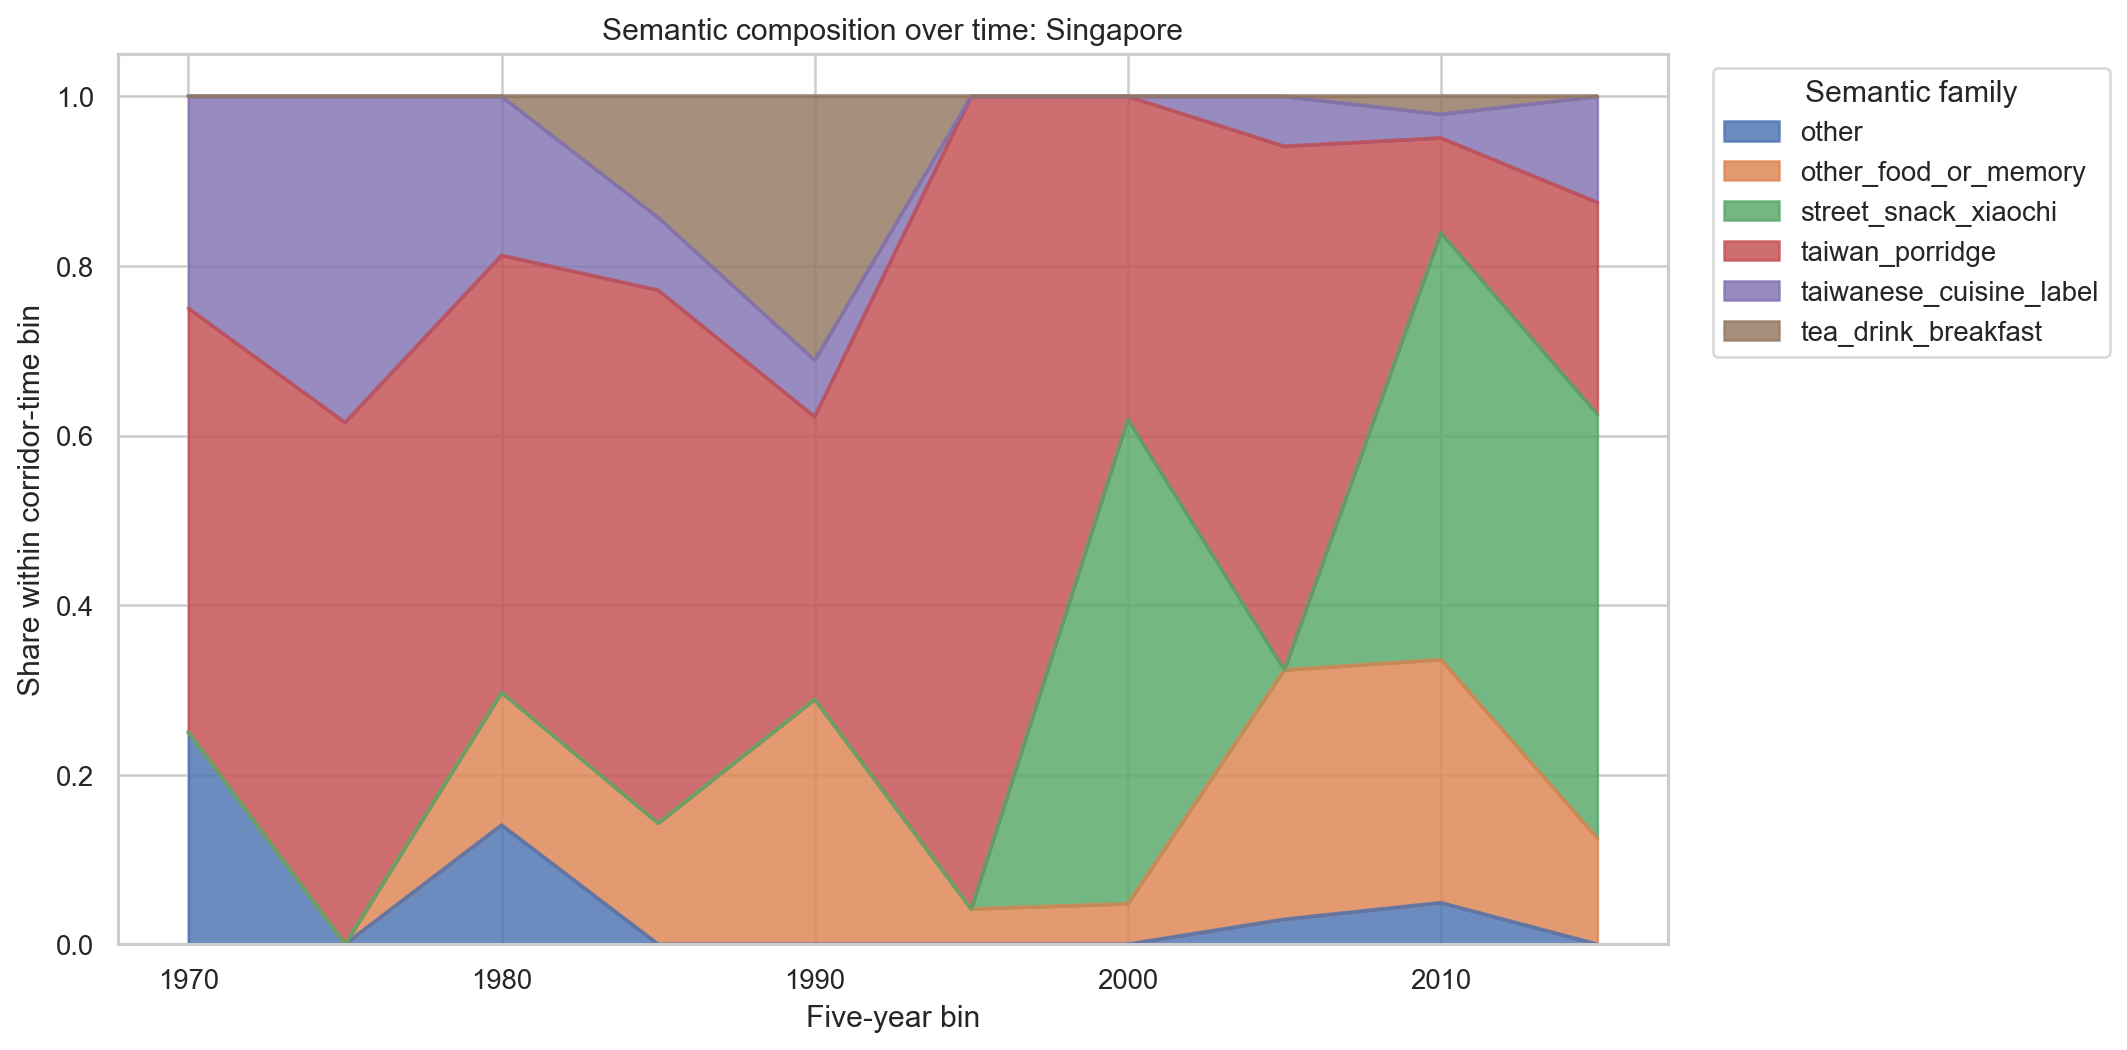

#### semantic stack Japan

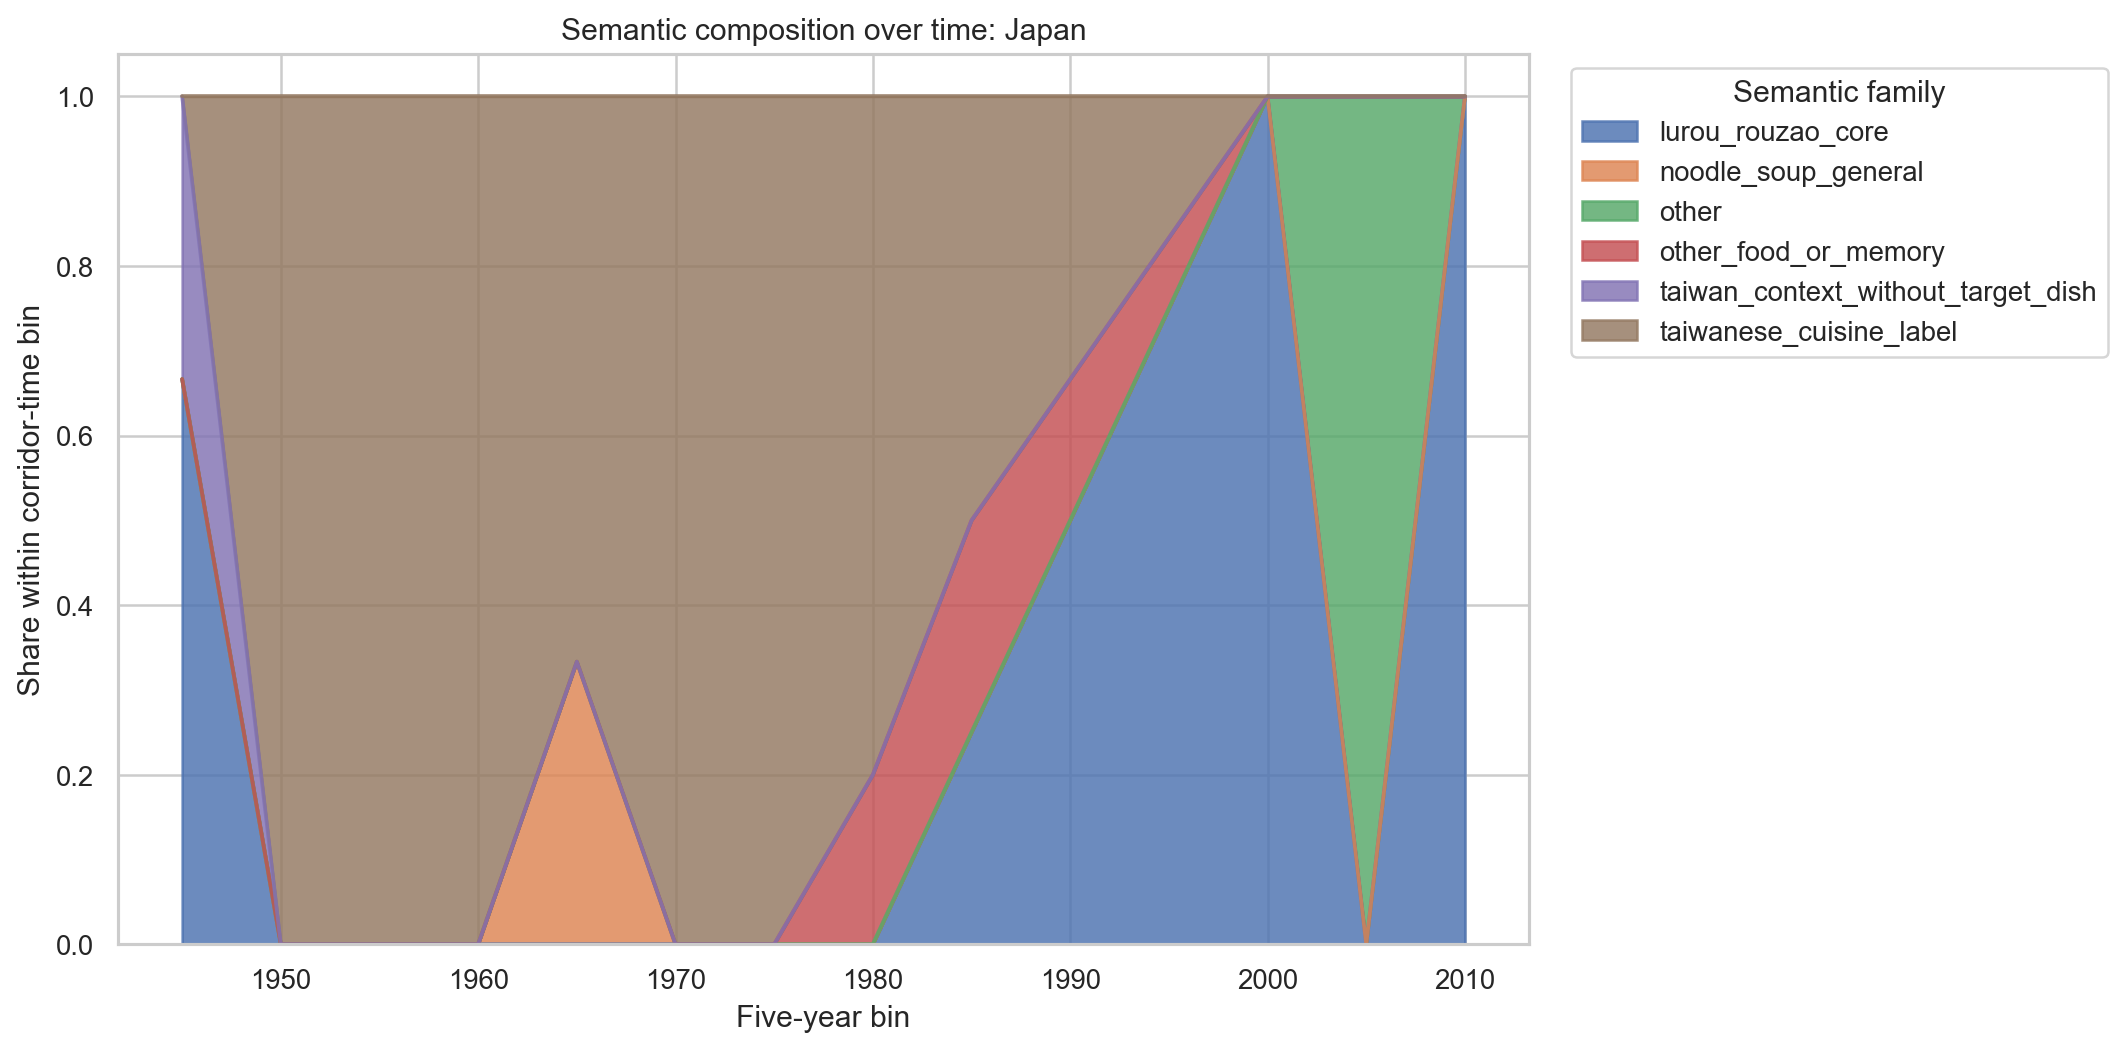

#### semantic stack North America

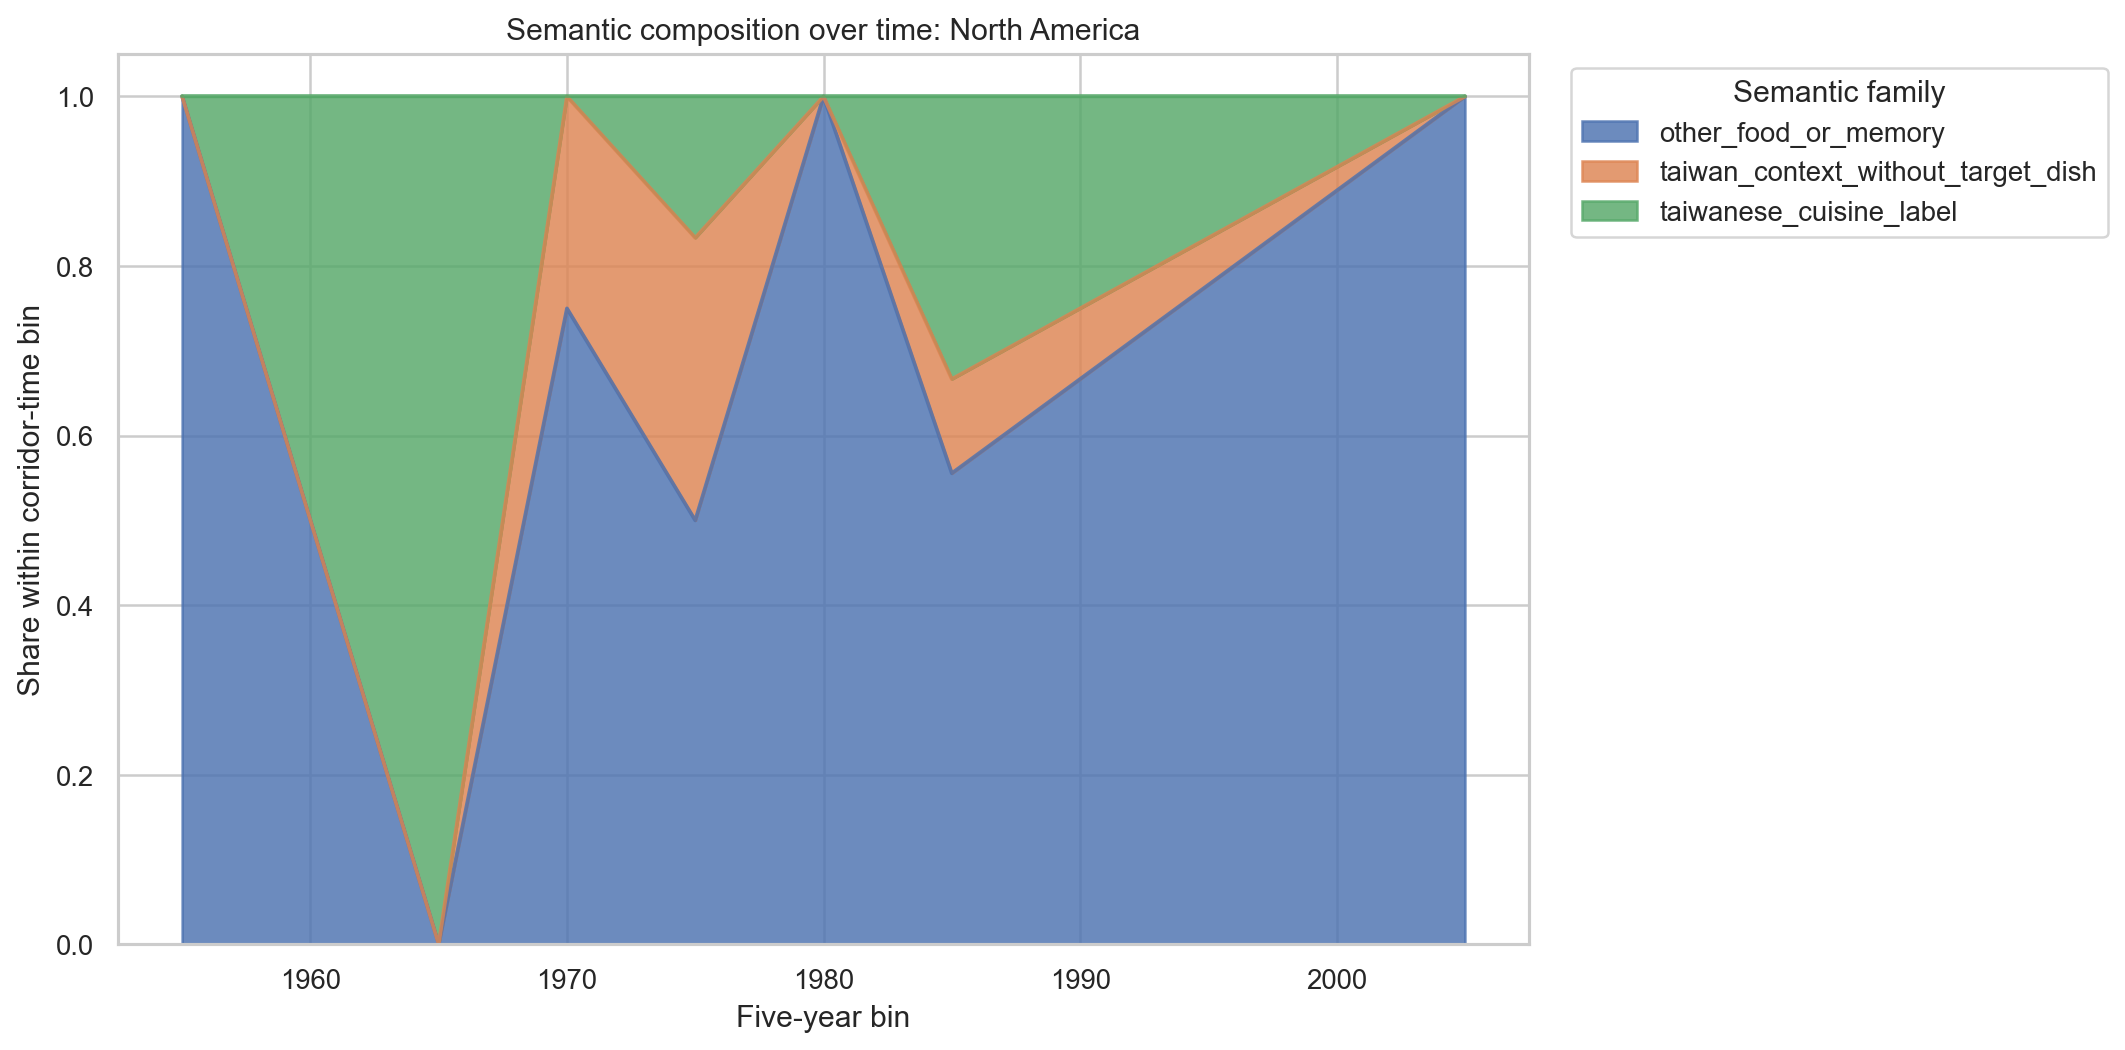

#### semantic stack Yangtze River Delta

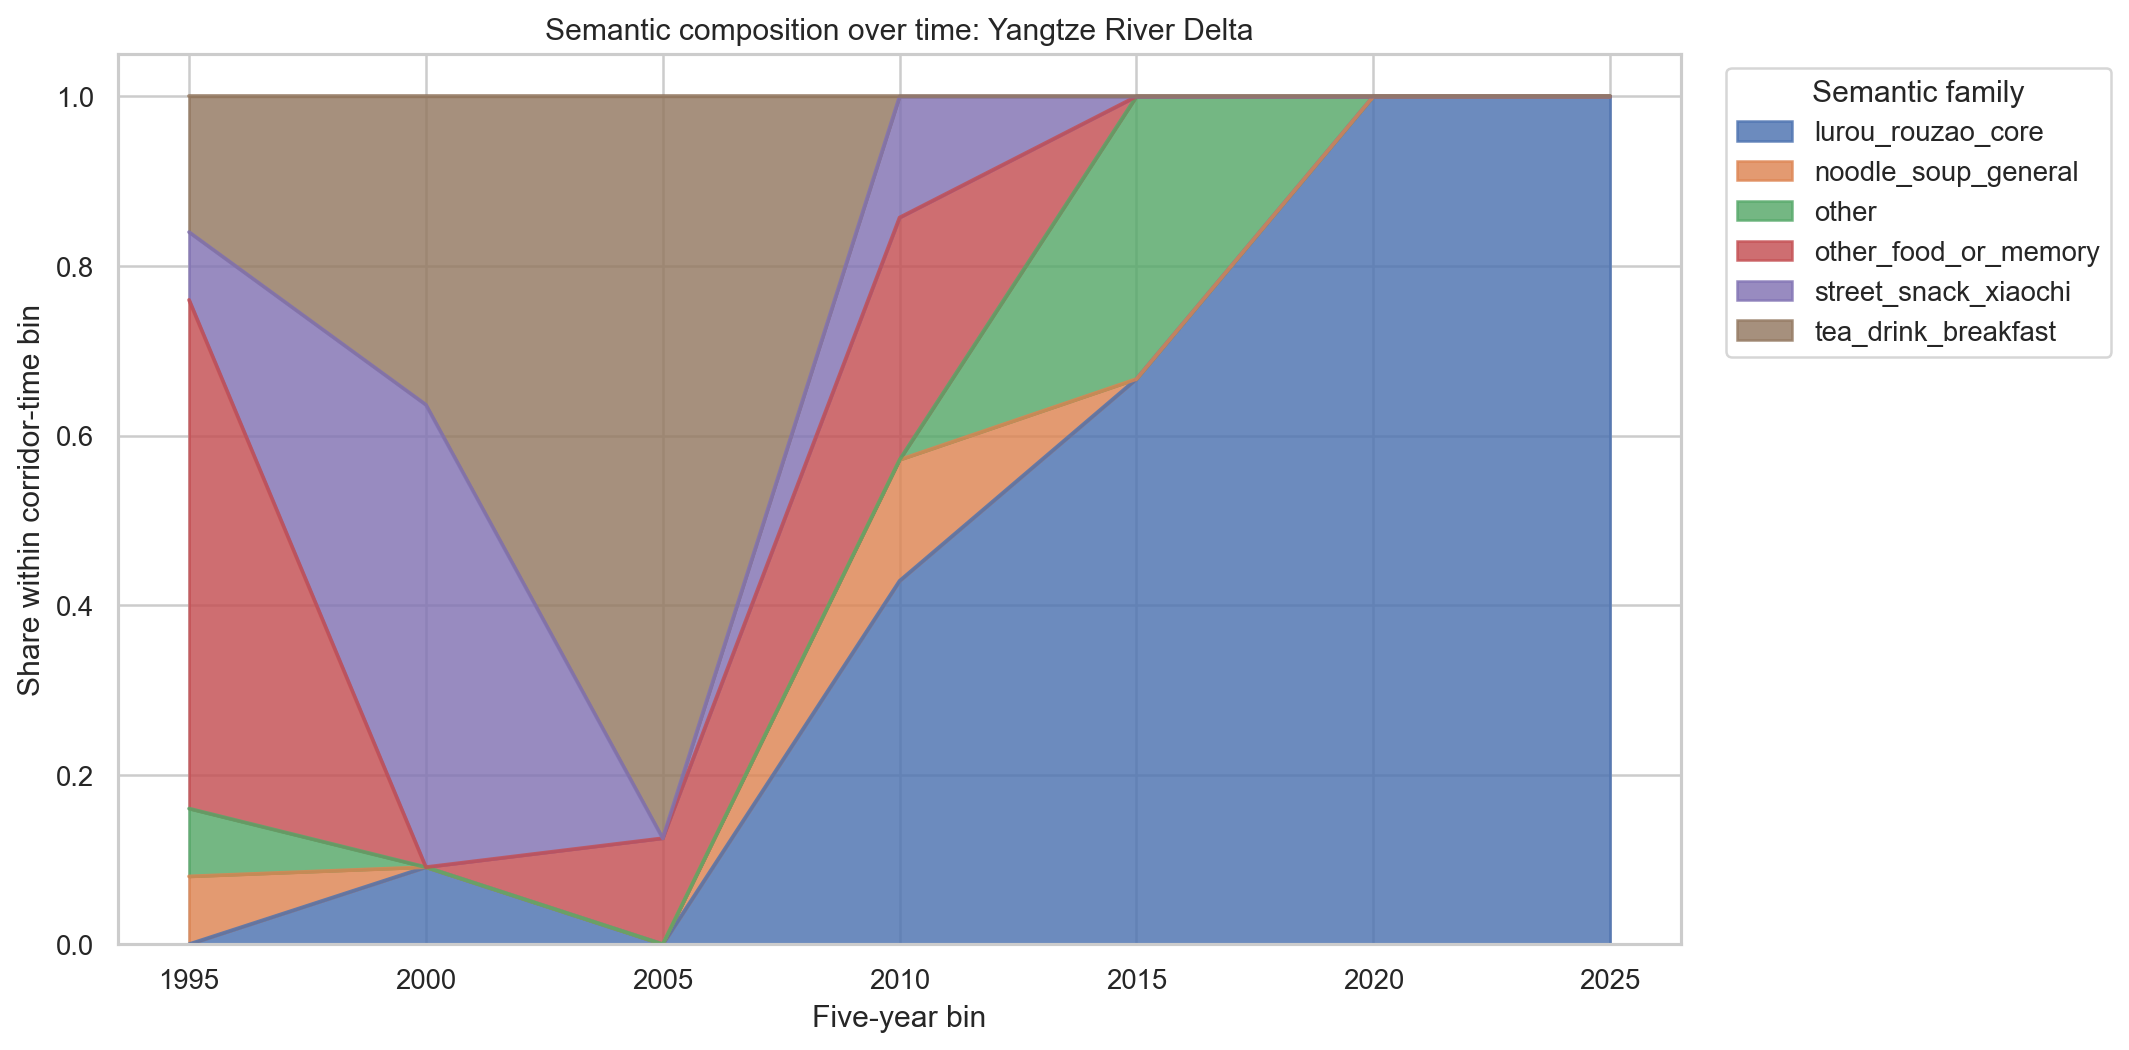

In [72]:
for fig_name in [
    "semantic_stack_Taiwan_side",
    "semantic_stack_Singapore",
    "semantic_stack_Japan",
    "semantic_stack_North_America",
    "semantic_stack_Yangtze_River_Delta",
]:
    if fig_name in FIGURES:
        display(Markdown(f"#### {fig_name.replace('_', ' ')}"))
        display(Image(filename=str(FIGURES[fig_name])))


### E. Discourse-frame stacks

These separate explicit Taiwan labels, nostalgia/memory frames, platform/commercial frames, and target controls. This is closer to semantic propagation than a raw binding-index trend.


#### discourse stack Taiwan side

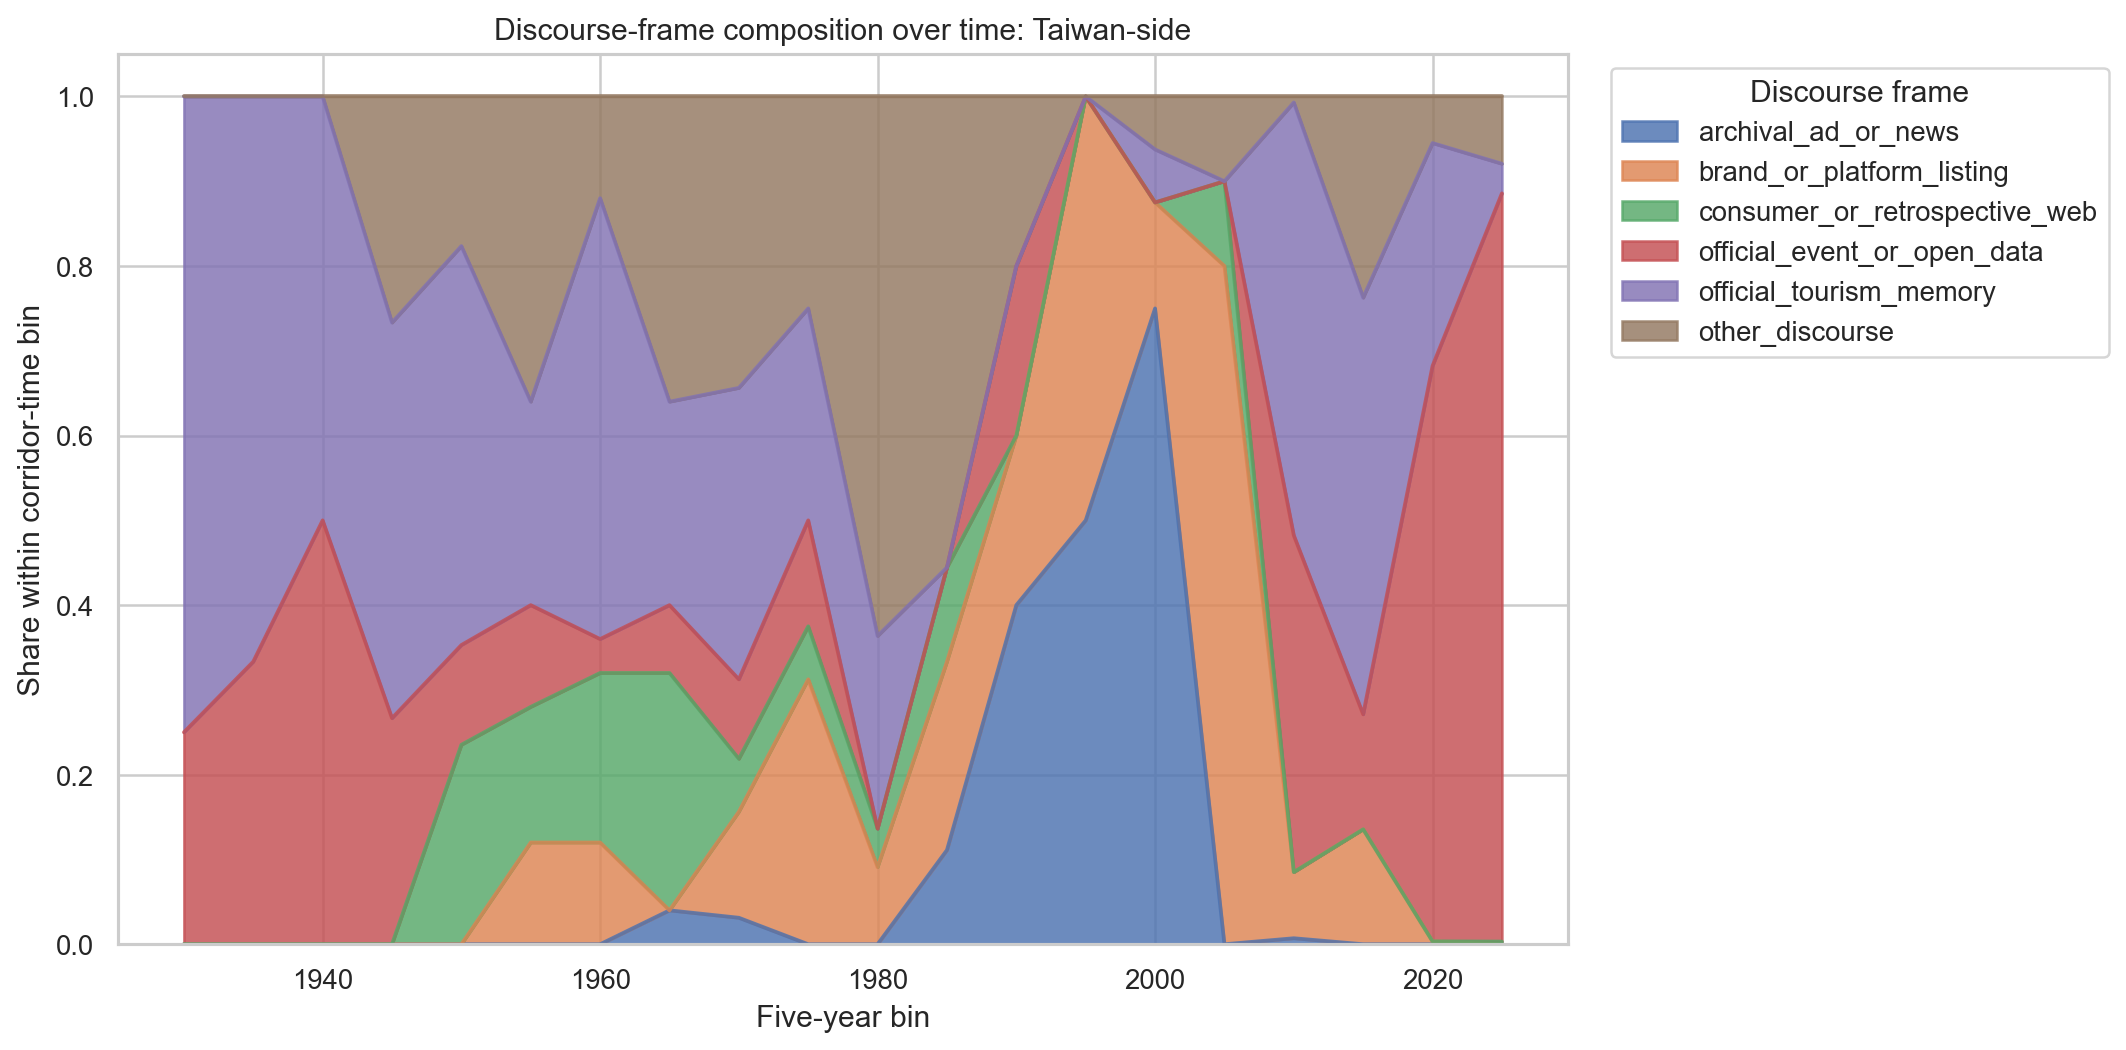

#### discourse stack Singapore

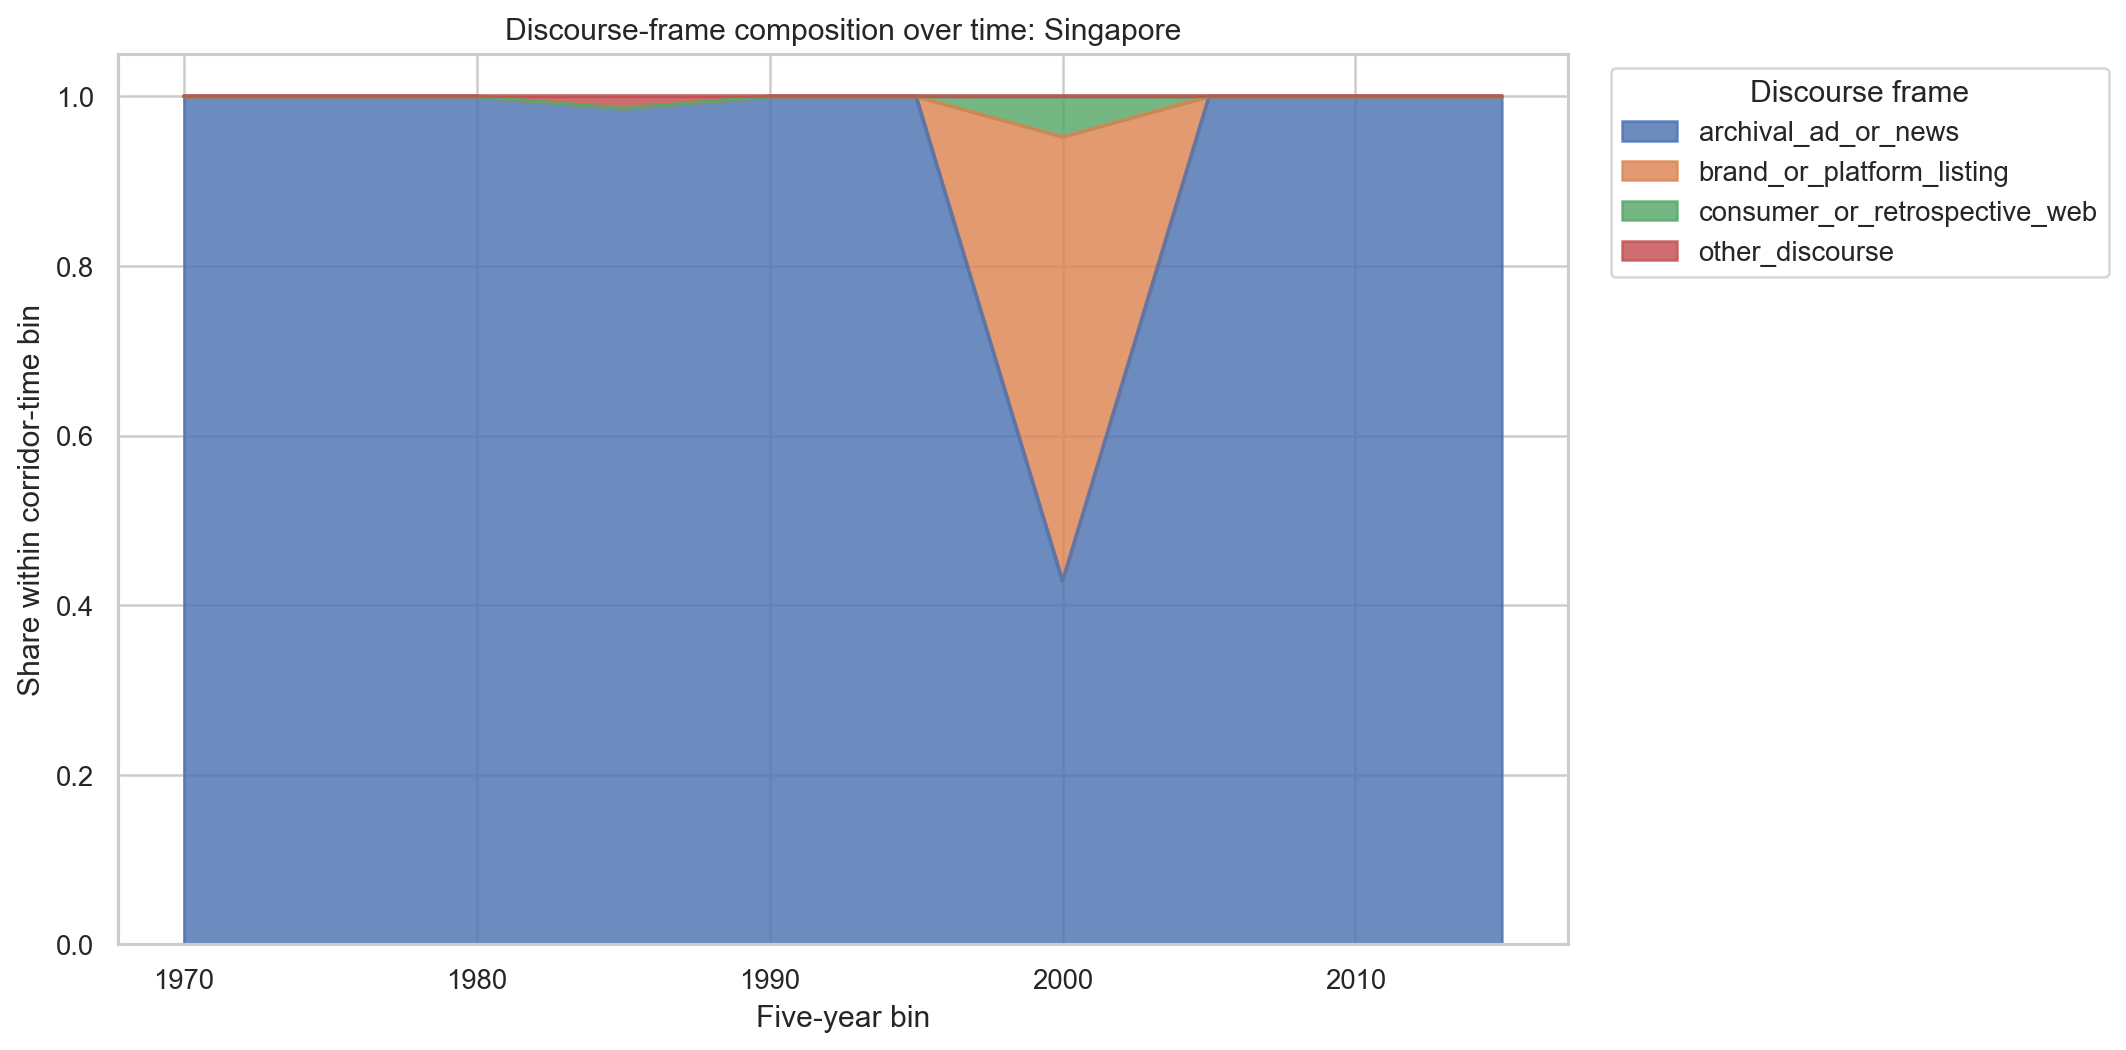

#### discourse stack Japan

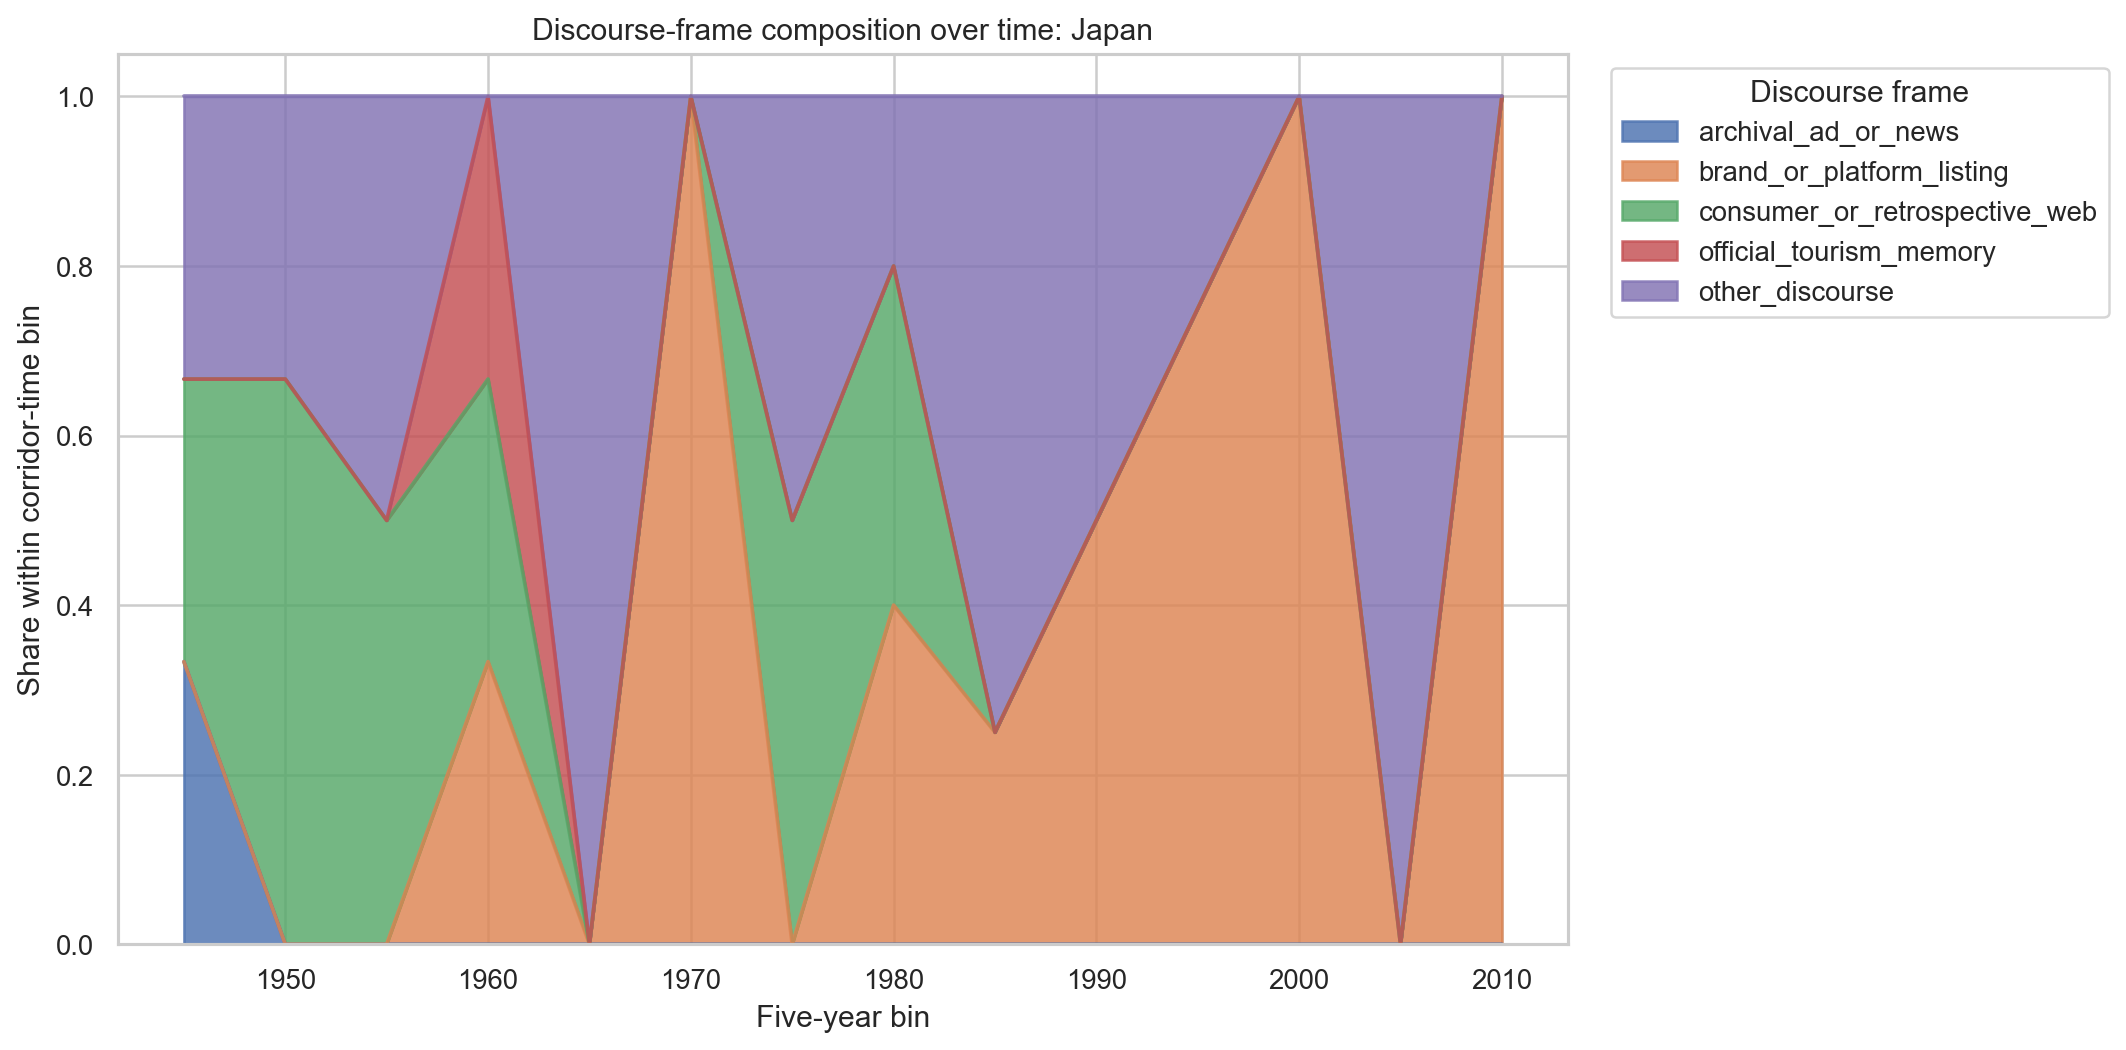

#### discourse stack North America

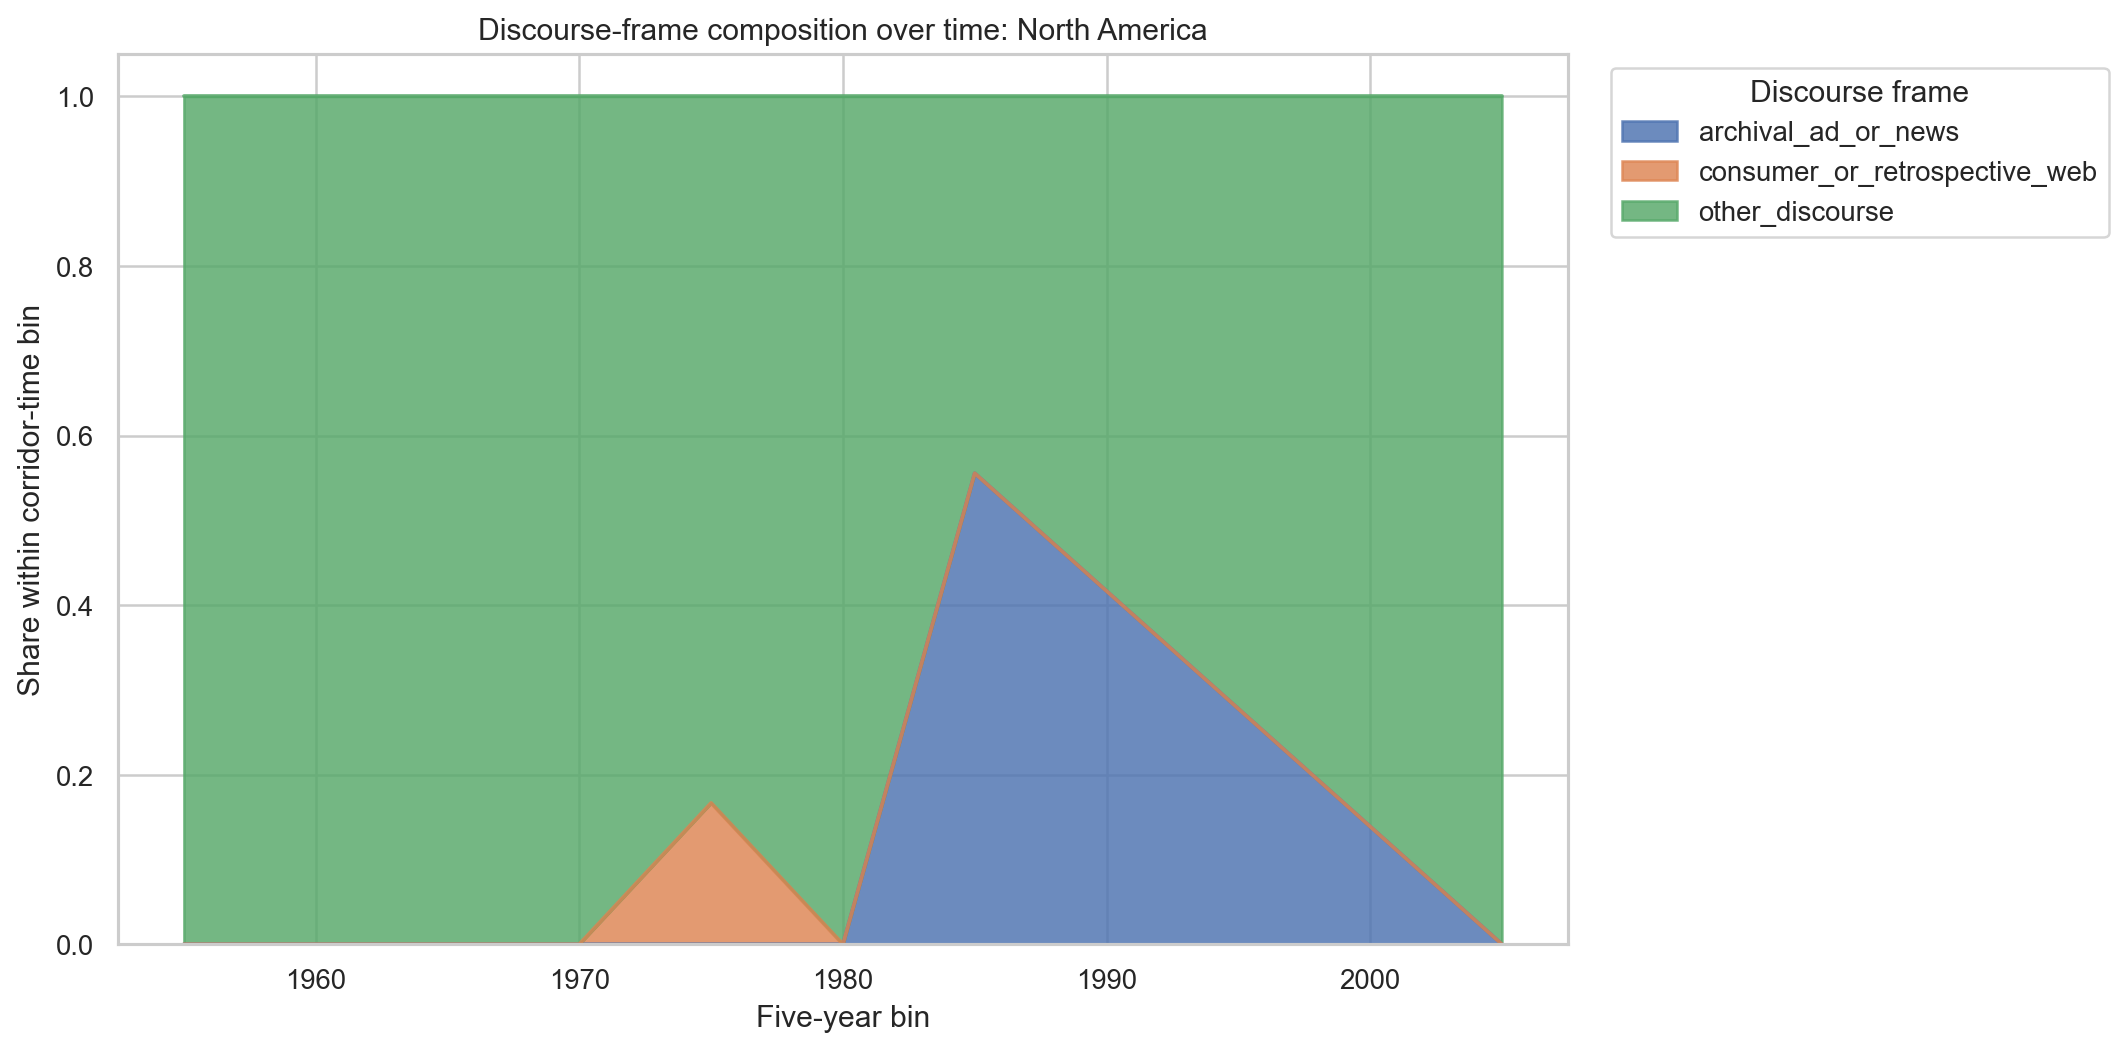

#### discourse stack Yangtze River Delta

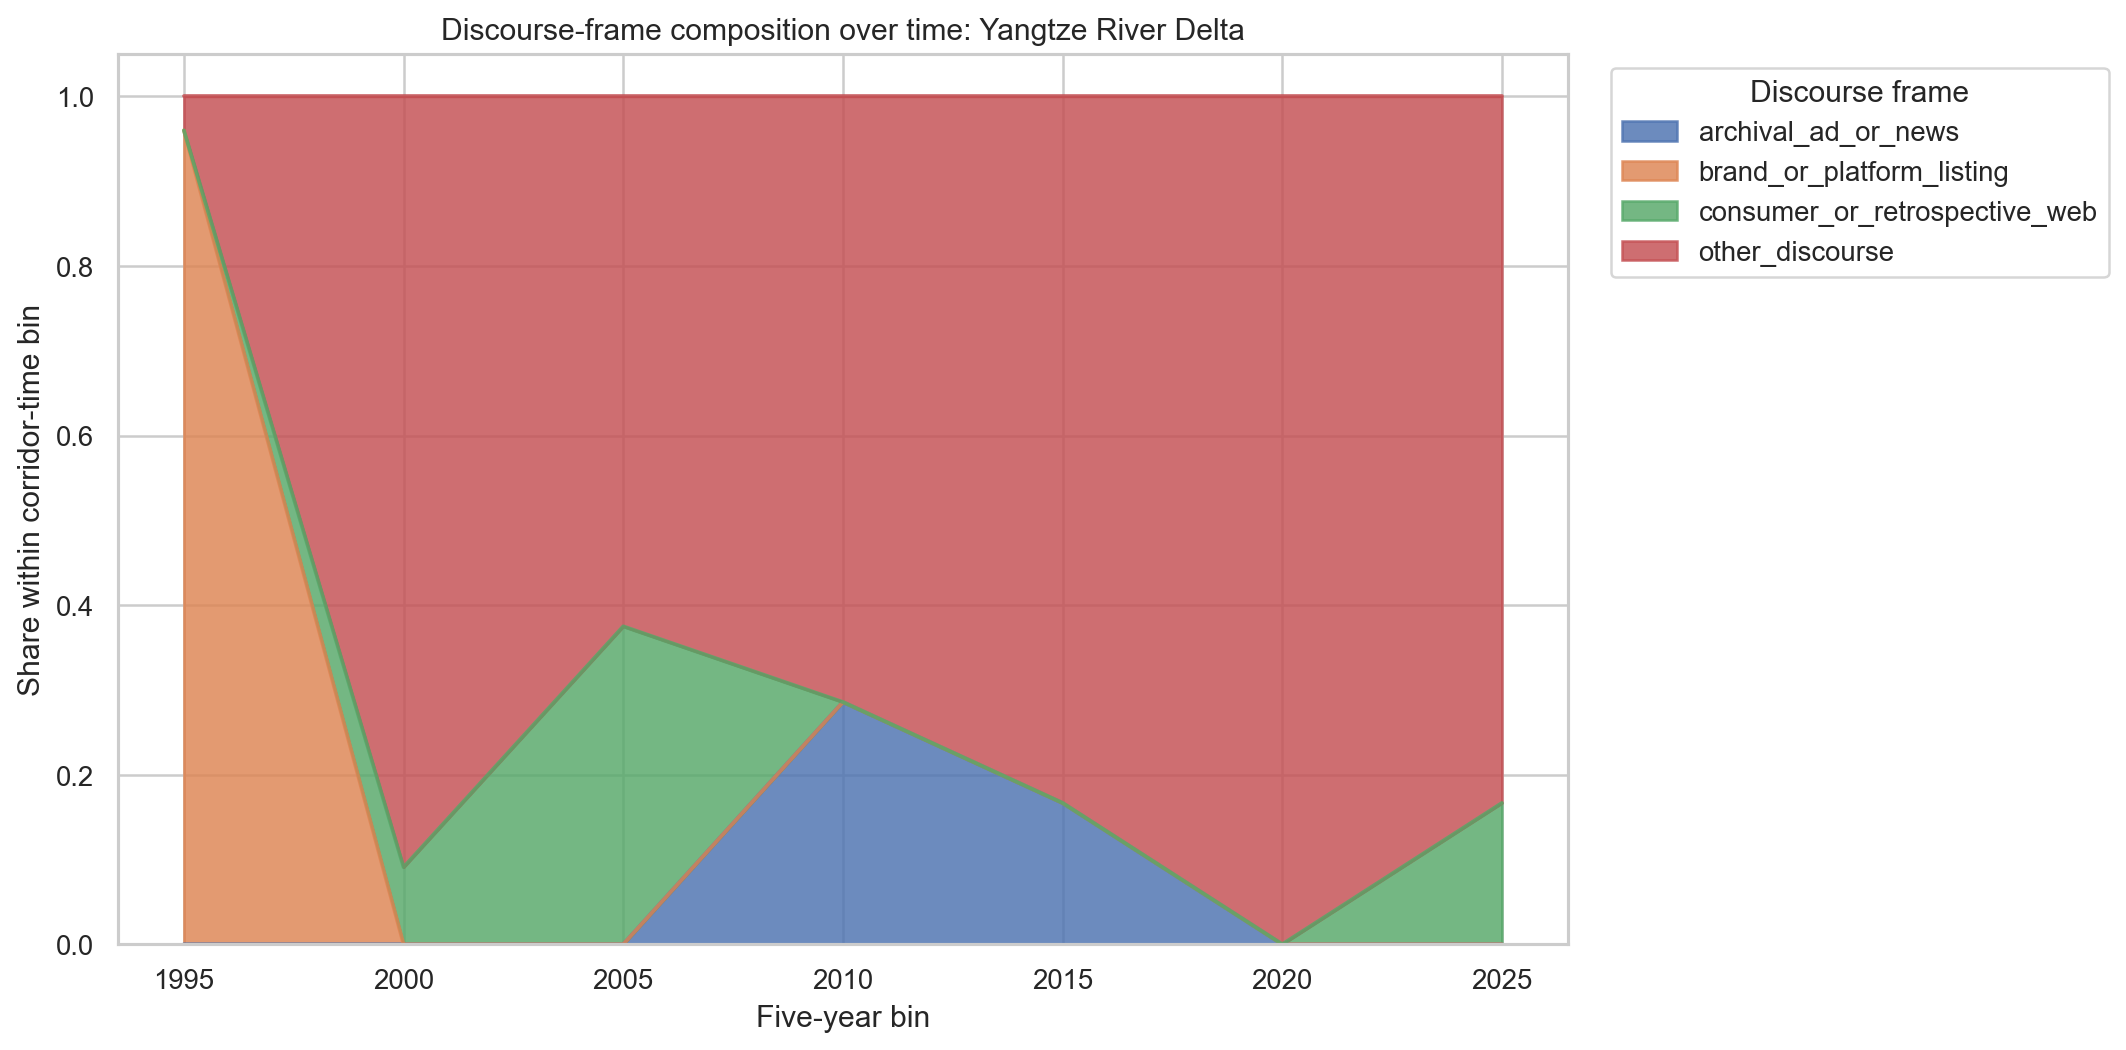

In [73]:
for fig_name in [
    "discourse_stack_Taiwan_side",
    "discourse_stack_Singapore",
    "discourse_stack_Japan",
    "discourse_stack_North_America",
    "discourse_stack_Yangtze_River_Delta",
]:
    if fig_name in FIGURES:
        display(Markdown(f"#### {fig_name.replace('_', ' ')}"))
        display(Image(filename=str(FIGURES[fig_name])))


### F. One analyzable table: time × geography × semantics × source type

This is the table to cite when you want the three layers in one place. Filter it by corridor, period, semantic family, or source type for close reading.


In [74]:
cube = pd.read_csv(TABLES["semantic_propagation_cube"])
cols = [
    "period", "five_year_bin", "corridor", "semantic_family",
    "taiwan_marker_frame", "discourse_frame", "source_type",
    "row_count", "weight_sum", "binding_index", "primary_rows", "unique_sources"
]
display(cube[cols].sort_values(["five_year_bin", "corridor", "row_count"], ascending=[True, True, False]).head(80))


KeyError: "['source_type'] not in index"

### G. Secondary robustness checks

Use these later, not as the main story. They identify weak-binding pockets and source-type sensitivity.


In [ ]:
display(Image(filename=str(FIGURES["low_binding_pockets"])))
display(Image(filename=str(FIGURES["leave_one_source_type_out"])))
display(pd.read_csv(TABLES["low_binding_pockets"]).head(25))
display(pd.read_csv(TABLES["leave_one_source_type_out"]).head(25))


## Producer-Consumer Transfer and Outlier Mining

This section adds two complementary analyses. Producer-consumer transfer is currently a small platform-layer sample, useful as a method demonstration. Outlier mining is stronger because it runs over the full frozen corpus and finds weak-binding pockets, target controls, and low-weight positive cases.


In [ ]:
TRANSFER_SCRIPT = ROOT / "scripts" / "producer_consumer_outlier_analysis.py"
subprocess.run([sys.executable, str(TRANSFER_SCRIPT)], check=True)
PCO_DIR = ROOT / "analysis" / "producer_consumer_outliers_outputs"
PCO_FIG = PCO_DIR / "figures"
PCO_TABLES = {p.stem: p for p in sorted(PCO_DIR.glob("*.csv"))}
PCO_FIGURES = {p.stem: p for p in sorted(PCO_FIG.glob("*.png"))}
display(pd.read_csv(PCO_TABLES["analysis_summary"]))
sorted(PCO_FIGURES)


### Producer-consumer marker transfer

Use cautiously: because the platform sample is small, this is a visual method demo and a qualitative clue, not a large-n statistical claim.


In [ ]:
display(Image(filename=str(PCO_FIGURES["producer_consumer_flow_matrix"])))
display(Image(filename=str(PCO_FIGURES["producer_consumer_funnel"])))
display(pd.read_csv(PCO_TABLES["producer_consumer_flow"]))
display(pd.read_csv(PCO_TABLES["producer_consumer_classified_reviews"]).head(20))


### Outlier mining: weak-binding and no-binding records

These figures are more useful for the thesis than another saturated trend line. They show where Taiwaneseness fails to attach, attaches weakly, or survives only through low-authority/low-novelty evidence.


In [ ]:
display(Image(filename=str(PCO_FIGURES["low_binding_outliers_scatter"])))
display(Image(filename=str(PCO_FIGURES["low_binding_time_corridor_heatmap"])))
display(Image(filename=str(PCO_FIGURES["low_binding_by_reason"])))
display(Image(filename=str(PCO_FIGURES["low_binding_by_source_type"])))


### Close-reading table for counterexamples

Use this table to choose cases where the marker chain breaks: dish-only, Taiwan-context-only, or low-weight positive evidence.


In [ ]:
examples = pd.read_csv(PCO_TABLES["low_binding_examples_for_close_reading"])
cols = ["attestation_id", "year", "period", "corridor", "source_type", "brand_or_category", "dish_marker", "taiwan_marker", "weighted_historical_binding", "outlier_reason", "source_ref"]
display(examples[cols].head(30))


## Change Points, Violin Distributions, and Authority-Novelty Surfaces

This section looks for structure when the overall binding trend is saturated. Change points use source-structure shifts; violin plots show distributional spread; authority-novelty surfaces diagnose how the weighting regime shapes the corpus.


In [ ]:
CAN_SCRIPT = ROOT / "scripts" / "change_point_authority_novelty_analysis.py"
subprocess.run([sys.executable, str(CAN_SCRIPT)], check=True)
CAN_DIR = ROOT / "analysis" / "change_authority_novelty_outputs"
CAN_FIG = CAN_DIR / "figures"
CAN_TABLES = {p.stem: p for p in sorted(CAN_DIR.glob("*.csv"))}
CAN_FIGURES = {p.stem: p for p in sorted(CAN_FIG.glob("*.png"))}
display(pd.read_csv(CAN_TABLES["analysis_summary"]))
sorted(CAN_FIGURES)


### A. Change points in source structure

The Taiwan-side binding line is saturated, so the more useful question is when source composition changes: newspaper/archive share, tourism-memory share, primary share, and tertiary share.


In [ ]:
display(Image(filename=str(CAN_FIGURES["change_points_taiwan_source_structure"])))
display(Image(filename=str(CAN_FIGURES["change_point_candidate_map"])))
change_points = pd.read_csv(CAN_TABLES["change_point_candidates"])
display(change_points.sort_values("change_score", ascending=False).head(30))


### B. Distributional view: violin plots and weak-binding share

This is often stronger than a line chart. It shows whether each corridor-period is tightly saturated, mixed, or actually contains weak-binding cases.


In [ ]:
display(Image(filename=str(CAN_FIGURES["violin_binding_by_corridor_period"])))
display(Image(filename=str(CAN_FIGURES["weak_binding_share_heatmap"])))
display(pd.read_csv(CAN_TABLES["binding_bucket_by_corridor_period"]).head(40))


### C. Authority-novelty diagnostic surfaces

Use these as method diagnostics, not causal findings. `authority_weight` and `novelty_score` are part of the weighting formula, so the point is to show how conservative weighting changes the evidence landscape.


In [ ]:
display(Image(filename=str(CAN_FIGURES["authority_novelty_empirical_heatmap"])))
display(Image(filename=str(CAN_FIGURES["authority_novelty_contour"])))
display(Image(filename=str(CAN_FIGURES["authority_novelty_contours_by_corridor"])))
display(pd.read_csv(CAN_TABLES["authority_novelty_surface_coefficients"]))
display(pd.read_csv(CAN_TABLES["authority_novelty_by_corridor_coefficients"]))
